# Does the Payout–Leverage Relationship Vary with the Interest Rate Regime?
### Industry-Level Evidence from US Non-Financial Firms, 1999–2025 — *analysis pipeline*

Milan Kalajdžić · University of Warsaw, Faculty of Economic Sciences · *Quantitative Finance MA*
Supervisor: dr hab. Piotr Boguszewski

---

Empirical pipeline for Chapters **4 (Data)**, **5 (Methodology)** and **6 (Results)**. It builds an
**industry × year panel** from the Damodaran datasets (1999–2025), merges macro series from **FRED**, and
estimates fixed-effects panel regressions of payout on leverage with a **leverage × rate-regime interaction**
(the central test of **H2**), plus the **H3** tangibility moderation.

> **Full 27-year panel.** Years are auto-detected from each file's internal date stamp (newer files) or its
> filename (older archives). The loader is **era-proof**: it handles Damodaran's three structural layouts
> (the 1999–2012 `Sheet1` files, the 2013–2017 transition, and the 2018+ `Industry Averages` files) and
> selects columns by keyword so year-to-year renames don't break it.

> **Two things the long panel changes vs an 8-year run:**
> 1. **Regime definition.** With 1999–2025 spanning several tightening cycles (early-2000s, mid-2000s,
>    2022+), the **rate-level threshold** is the primary regime variable (not the post-2022 binary, which
>    would lump 23 disparate years together). Both are reported.
> 2. **Industry reconciliation.** Damodaran reorganised his classification at **2012→2013**. A conservative
>    rename map fixes unambiguous variants; a **stable-core sample** (industries present ≥ N years) provides
>    a robustness check immune to the reclassification. See §2 and Appendix B.

> 3. **Data-quality fixes (Sept 2026).** Damodaran's 2013–2015 capex files report depreciation on a
>    different basis (industry depreciation roughly halves while capex does not), which inflates
>    Cap Ex/Depreciation and scrambles the industry ranking. Depreciation-based tangibility is set to missing
>    in those years (per-year check in §2). The H3 model now includes the tangibility main effect, and the
>    H3 proxy-robustness loop applies the same industry reconciliation as the main panel.

> 4. **`dbtfund` (Sept 2026).** Tangibility for H3 is now **PP&E / total assets**, the standard measure, used as a
>    within-year percentile rank because its definition changes in 2013 and 2017; the capex proxies become
>    robustness checks. Book leverage, market leverage without leases and **Debt/EBITDA** (debt relative to
>    cash flow, the closest available measure of debt-service burden) re-test H1/H2 in §9d.

| Section | Thesis |
|---|---|
| 0 Setup · 1 Load · 2 Filters & reconciliation | §5.6, §4.1–4.2, App. B |
| 3 FRED & regime · 4 Variables | §4.1, §4.3 |
| 5 Descriptives · 6 Baseline · 7 Interaction (H1/H2) · 8 Tangibility (H3) · 8b Dividend smoothing | §4.4, §5–6 |
| 9 Robustness · 10 Tables & verdicts · 11 Figures · 12 Reproducibility | §5.5, §6, App. A/C/D |

## 0 · Setup & configuration  <span style="color:gray">(§5.6)</span>

In [1]:
# Install once:  pip install -r requirements.txt

import warnings, sys, platform, re
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 70)
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": .3})
try:
    from linearmodels.panel import PanelOLS
    HAVE_LM = True
except Exception:
    HAVE_LM = False; print("linearmodels missing -> %pip install linearmodels")
print("Python", sys.version.split()[0], "| pandas", pd.__version__)

Python 3.11.15 | pandas 3.0.2


In [2]:
# ============================ CONFIGURATION ============================
SEARCH_DIRS = ["data", "."]   # searched recursively for the Damodaran .xls files; absent paths ignored

# Tangibility for H3 (see §4).
#   "ppe_assets"     -> PP&E / total assets from dbtfund  (PRIMARY: the standard measure, e.g. Rajan & Zingales 1995)
#                       Its definition changes twice (PPE_DEF_CHANGES): Fixed Assets/BV of Capital (1999-2012),
#                       Fixed Assets/Total Assets (2013-2016), Net PP&E/Total Assets (2017+). It is therefore used
#                       as a percentile rank within each year, which is comparable across the definitions.
#   "capex_deprec"   -> Cap Ex / Depreciation            (robustness)
#   "netcapex_sales" -> Net Cap Ex / Sales                (robustness)
#   "invcap_sales"   -> 1 / (Sales / Invested Capital)   (robustness)
TANGIBILITY_PROXY = "ppe_assets"
CAPEX_PROXIES     = {"capex_deprec", "netcapex_sales", "invcap_sales"}
PPE_DEF_CHANGES   = [2013, 2017]
# Damodaran's 2013-2015 capex files report depreciation on a different basis (industry depreciation drops
# by roughly half vs 2012/2016 while capex does not), inflating Cap Ex/Depreciation and scrambling the
# industry ranking. Proxies built from depreciation are set to missing in these years (see the §2 check).
TANG_BREAK_YEARS = [2013, 2014, 2015]
DEPREC_PROXIES   = {"capex_deprec", "netcapex_sales"}

# Rate regime (§4.3.3). With the long panel the threshold captures multiple cycles.
HIGH_RATE_RULE = "threshold"   # "threshold" (primary) or "post2022"
FFR_THRESHOLD  = 3.0           # annual-avg fed funds % defining "high"
HIKE_THRESHOLD = 0.25          # rise in annual-avg fed funds (pp) that counts as a hiking year (§8b)
RECLASS_YEAR   = 2013          # Damodaran's industry reclassification: year-on-year changes across it are
                               # composition shifts, so change/lag models in §8b drop this year

# Equivalence test for H2 (§9b): largest regime effect still considered economically negligible,
# in payout-ratio units per 1 SD of leverage (0.05 is about 14% of the mean payout of 0.35).
EQUIV_MARGIN = 0.05

# FRED macro data:
#   "snapshot" -> pinned monthly/quarterly vintage in data/fred/fred_snapshot.csv (exactly reproducible)
#   "live"     -> download the current vintage with pandas-datareader (GDP is revised over time)
FRED_SOURCE   = "snapshot"
FRED_SNAPSHOT = Path("data/fred/fred_snapshot.csv")

# Sample construction
WINSOR_P         = 0.01
# Ratios are undefined when their denominator is not positive (payout = D/earnings, D/FCFE, total payout/NI).
# Damodaran still reports values there (e.g. payout ~0.003 for loss-making industries that pay dividends),
# so they are set to missing. The as-reported payout is kept as a robustness check (§9).
POSITIVE_DENOMINATORS = True
CROSSFILE_MIN_AGREE = 0.75     # min share of industries whose divfund payout matches divfcfe D/NI (±5%)
# Row alignment (§2): an industry has the same number of firms in every file of a year. In a file-year where
# most counts match divfund, a row whose count differs belongs to another industry (e.g. wacc99, where a block
# of rows is shifted by one) and that file's variables are set to missing for it. Where most counts differ,
# the file is a different vintage of the universe and is left as it is (reported in the alignment table).
ALIGN_MIN_SHARE = 0.5
EXCLUDE_FIN_UTIL = True
MIN_YEARS_CORE   = 20          # stable-core robustness: keep industries present >= this many years
COVID_YEARS      = [2020, 2021]
DK_BANDWIDTH     = 3           # lags for Driscoll-Kraay standard errors (about T^(1/3) with 27 years, §9)
RW_BOOT          = 999         # industry-cluster bootstrap draws for the Romano-Wolf adjustment (§10b)
RW_SEED          = 2026

OUTDIR = Path("outputs"); OUTDIR.mkdir(exist_ok=True)
print("Config OK | regime:", HIGH_RATE_RULE, "| tangibility:", TANGIBILITY_PROXY,
      "| core>=", MIN_YEARS_CORE, "yrs | FRED:", FRED_SOURCE)

Config OK | regime: threshold | tangibility: ppe_assets | core>= 20 yrs | FRED: snapshot


## 1 · Load the Damodaran datasets  <span style="color:gray">(§4.1–4.2)</span>

`divfund` (payout, ROE, market cap) · `divfcfe` (dividends, FCFE) · `wacc` (leverage D/(D+E), tax) ·
`capex` (capex-based tangibility proxies) ·
`dbtfund` (PP&E / assets, book and lease-unadjusted leverage, EBITDA / EV). The readers below are **era-proof**: they locate the industry sheet and header
row wherever they sit, derive the data year from the internal stamp or filename, and match columns by
keyword. *Verified against every file from 1999 to 2025.*

In [3]:
def read_industry_sheet(path, scan=45):
    """Locate and read the industry table across all Damodaran layouts (1999-2025)."""
    xl = pd.ExcelFile(path)
    named = [s for s in xl.sheet_names if "industry" in s.lower()]
    for sh in named + [s for s in xl.sheet_names if s not in named]:
        raw = pd.read_excel(path, sheet_name=sh, header=None, nrows=scan)
        if raw.empty:
            continue
        for i in range(len(raw)):
            if str(raw.iloc[i, 0]).strip().lower().startswith("industry"):
                df = pd.read_excel(path, sheet_name=sh, header=i).dropna(how="all")
                df = df.rename(columns={df.columns[0]: "industry"})
                df["industry"] = df["industry"].astype(str).str.strip()
                return df[df["industry"].str.lower() != "nan"].copy()
    raise ValueError(f"No industry table found in {path}")

def pick(df, *keys):
    keys = [k.lower() for k in keys]
    for c in df.columns:
        if all(k in str(c).lower() for k in keys):
            return c
    return None

def pick_fcfe(df):
    """FCFE level column (not a ratio): starts with 'fcfe', no '/'. Prefers 'before debt'."""
    for c in df.columns:
        cl = str(c).lower().strip()
        if cl.startswith("fcfe") and "/" not in str(c):
            return c
    return None

def pick_div(df):
    """Dividend level column ($), excluding ratios, buybacks, payout, yield."""
    for c in df.columns:
        cl = str(c).lower()
        if "dividend" in cl and "/" not in str(c) and not any(
                e in cl for e in ["yield", "buyback", "net income", "payout"]):
            return c
    return None

def data_year(path):
    """Data year: internal 'Date updated' stamp (year-1) if present, else filename (Y2K pivot)."""
    try:
        xl = pd.ExcelFile(path)
        for sh in xl.sheet_names:
            raw = pd.read_excel(path, sheet_name=sh, header=None, nrows=6)
            for i in range(len(raw)):
                if "date updated" in str(raw.iloc[i, 0]).lower():
                    return pd.to_datetime(raw.iloc[i, 1]).year - 1
    except Exception:
        pass
    m = re.search(r"(\d{2,4})(?=\D*$)", Path(path).stem)
    if m:
        n = int(m.group(1))
        return n if n >= 100 else (1900 + n if n >= 50 else 2000 + n)
    return None

def discover_sources(token):
    found = {}
    for d in SEARCH_DIRS:
        d = Path(d)
        if not d.exists():
            continue
        for f in sorted(d.rglob(f"{token}*.xls*")):
            # token + optional year digits only (so e.g. dbtfundEurope24.xls is not read as dbtfund)
            if f.name.startswith("~$") or not re.fullmatch(rf"{token}\d*\.xlsx?", f.name, re.I):
                continue
            y = data_year(f)
            if y is not None:
                found.setdefault(y, f)
    return found

In [4]:
# capex-based tangibility proxies (see §4); the primary PP&E measure comes from dbtfund
def _tangibility(cx):
    if TANGIBILITY_PROXY == "netcapex_sales":
        c = pick(cx, "net cap ex", "sales") or pick(cx, "cap ex", "sales")
    elif TANGIBILITY_PROXY == "invcap_sales":
        c = pick(cx, "sales", "capital") or pick(cx, "sales", "invested")
        if c is None:                          # column absent in older capex files
            return pd.Series(np.nan, index=cx.index)
        return 1.0 / pd.to_numeric(cx[c], errors="coerce").replace(0, np.nan)
    else:
        c = pick(cx, "cap ex", "deprec")       # capex_deprec (present every year)
    if c is None:
        return pd.Series(np.nan, index=cx.index)
    return pd.to_numeric(cx[c], errors="coerce")

def _nfirms(df):
    c = pick(df, "number", "firm")
    return pd.to_numeric(df[c], errors="coerce") if c else np.nan

def load_year(year):
    dv = read_industry_sheet(SOURCES["divfund"][year])
    wc = read_industry_sheet(SOURCES["wacc"][year])
    out = pd.DataFrame({"industry": dv["industry"], "year": year})
    out["payout"] = pd.to_numeric(dv[pick(dv, "dividend", "payout")], errors="coerce")
    out["roe"]    = pd.to_numeric(dv[pick(dv, "roe")], errors="coerce")
    nf = pick(dv, "number", "firm")
    out["n_firms"] = pd.to_numeric(dv[nf], errors="coerce") if nf else np.nan   # weights (§9)
    mc = pick(dv, "market cap")
    out["mktcap"] = pd.to_numeric(dv[mc], errors="coerce") if mc else np.nan
    out = out.merge(pd.DataFrame({
        "industry": wc["industry"],
        "lev": pd.to_numeric(wc[pick(wc, "d/(d+e)")], errors="coerce"),
        "tax": pd.to_numeric(wc[pick(wc, "tax")], errors="coerce"),
        "nf_wacc": _nfirms(wc),                    # row-alignment check (§2)
    }), on="industry", how="left")
    if year in SOURCES["divfcfe"]:
        fc = read_industry_sheet(SOURCES["divfcfe"][year])
        dcol, fcol = pick_div(fc), pick_fcfe(fc)
        tot, ni = pick(fc, "dividends", "buyback"), pick(fc, "net income")
        f = pd.DataFrame({"industry": fc["industry"], "nf_divfcfe": _nfirms(fc)})
        if dcol:
            f["div_usd"] = pd.to_numeric(fc[dcol], errors="coerce")   # $m, used for checks and §8b
        if ni:
            f["ni_usd"] = pd.to_numeric(fc[ni], errors="coerce")
        def _den(col):                                  # denominator; <= 0 -> undefined ratio
            s = pd.to_numeric(fc[col], errors="coerce")
            return s.where(s > 0) if POSITIVE_DENOMINATORS else s.replace(0, np.nan)
        if dcol and fcol:
            f["div_to_fcfe"] = pd.to_numeric(fc[dcol], errors="coerce") / _den(fcol)
        if tot and ni:
            f["totpayout_ni"] = pd.to_numeric(fc[tot], errors="coerce") / _den(ni)
        out = out.merge(f, on="industry", how="left")
        if "div_usd" in out:                        # earnings-free payout measure (§9 ROE check)
            out["div_yield"] = out["div_usd"] / out["mktcap"].where(out["mktcap"] > 0)
    if year in SOURCES["capex"]:
        cx = read_industry_sheet(SOURCES["capex"][year])
        g = pd.DataFrame({"industry": cx["industry"], "nf_capex": _nfirms(cx),
                          "capex_deprec": pd.to_numeric(cx[pick(cx, "cap ex", "deprec")], errors="coerce")})
        if TANGIBILITY_PROXY in CAPEX_PROXIES:
            g["tangibility"] = _tangibility(cx)
        out = out.merge(g, on="industry", how="left")
    if year in SOURCES["dbtfund"]:
        db = read_industry_sheet(SOURCES["dbtfund"][year])
        num = lambda c: pd.to_numeric(db[c], errors="coerce") if c else np.nan
        g = pd.DataFrame({
            "industry": db["industry"], "nf_dbtfund": _nfirms(db),
            # market D/(D+E) without the lease adjustment (wacc's D/(D+E) includes leases from 2013 on)
            "lev_unadj": num(pick(db, "mv debt ratio") or pick(db, "market debt to capital", "unadjusted")),
            "lev_book": num(pick(db, "bv debt ratio") or pick(db, "book debt to capital")),
            "ebitda_ev": num(pick(db, "ebitda/")),                       # EBITDA / firm value (every year)
            "ppe_assets": num(pick(db, "fixed assets/") or pick(db, "pp&e/")),
            "debt_ebitda_rep": num(pick(db, "debt", "ebitda")),           # reported only 2018, 2022+
            "int_cov": num(pick(db, "interest coverage")),                # reported only 2022+
        })
        if TANGIBILITY_PROXY == "ppe_assets":
            g["tangibility"] = g["ppe_assets"]
        out = out.merge(g, on="industry", how="left")
    return out

SOURCES = {t: discover_sources(t) for t in ["divfund", "divfcfe", "wacc", "capex", "dbtfund"]}
all_years = sorted(set().union(*[set(v) for v in SOURCES.values()]))
grid = pd.DataFrame({t: ["Y" if y in SOURCES[t] else "." for y in all_years] for t in SOURCES},
                    index=all_years)
grid.index.name = "year"
print(f"Coverage ({len(all_years)} years {min(all_years)}-{max(all_years)}):")
print(grid.T.to_string())

years = sorted(set(SOURCES["divfund"]) & set(SOURCES["wacc"]))
raw = pd.concat([load_year(y) for y in years], ignore_index=True)
print(f"\nRaw panel: {len(years)} years | {raw['industry'].nunique()} distinct names | {len(raw)} rows")
raw.head()

Coverage (27 years 1999-2025):
year    1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025
divfund    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y
divfcfe    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y
wacc       Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y
capex      Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y
dbtfund    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y



Raw panel: 27 years | 219 distinct names | 2652 rows


,industry,year,payout,roe,n_firms,mktcap,lev,tax,nf_wacc,nf_divfcfe,div_usd,ni_usd,div_to_fcfe,div_yield,nf_capex,capex_deprec,nf_dbtfund,lev_unadj,lev_book,ebitda_ev,ppe_assets,debt_ebitda_rep,int_cov,tangibility,totpayout_ni
0,Advertising,1999,0.246424,0.134948,28,58326.4895,0.098560,0.447821,28.0,28.0,266.0,1079.0,0.214171,0.004561,28.0,0.852036,28.0,0.098560,0.469885,0.070291,0.155017,NaN,NaN,0.155017,NaN
1,Aerospace/Defense,1999,0.245589,0.133937,48,111866.7804,0.267524,0.348131,48.0,48.0,1455.0,5926.0,0.254460,0.013007,48.0,0.902343,48.0,0.267524,0.479951,0.138195,0.162030,NaN,NaN,0.162030,NaN
2,Air Transport,1999,0.052681,0.189568,42,84075.3787,0.346738,0.372312,42.0,42.0,385.0,7314.0,0.434537,0.004579,42.0,2.203980,42.0,0.346738,0.553515,0.223271,0.591270,NaN,NaN,0.591270,NaN
3,Alternate Energy,1999,0.118465,0.139224,5,13400.0999,NaN,NaN,NaN,5.0,55.0,461.0,0.364238,0.004104,5.0,1.849453,5.0,0.483904,0.820724,0.097176,0.472635,NaN,NaN,0.472635,NaN
4,Aluminum,1999,0.166057,0.092600,9,35307.2390,0.483904,0.288303,5.0,9.0,259.0,1562.0,0.447323,0.007336,9.0,1.279888,9.0,0.220551,0.410099,0.158002,0.196418,NaN,NaN,0.196418,NaN


## 2 · Sample construction, filters & industry reconciliation  <span style="color:gray">(§4.2, App. B)</span>

- Drop aggregate rows; exclude **financials & regulated utilities** (era-aware keyword list).
- **Reconcile industry names** across the 2012→2013 reclassification via a *conservative* map — only
  unambiguous spelling/punctuation variants and clear 1:1 relabels (extend `INDUSTRY_RENAME` as needed).
- Set depreciation-based tangibility to missing in the 2013–2015 break years (see the data check below).
- Winsorise ratio variables; report industry **persistence** (Appendix B) and define the **stable core**.

In [5]:
AGG_ROWS = ["Total Market", "Total Market (without financials)", "Grand Total",
            "Market", "Other", "Unclassified"]
# era-aware financial / regulated-utility exclusions (lower-cased substring match)
FIN_UTIL_KEYS = ["bank", "insurance", "financ", "investment", "utilit", "power", "r.e.i.t", "reit",
                 "reinsurance", "brokerage", "trust", "thrift", "securities", "electric util",
                 "natural gas (distrib", "natural gas util", "water utility", "telecom. utility",
                 "public/private equity", "real estate"]

# Conservative reconciliation: unambiguous variants + clear 1:1 relabels only.
INDUSTRY_RENAME = {
    # --- spelling / punctuation / typo variants ---
    "Furn./Home Furnishings": "Furn/Home Furnishings",
    "Paper & Forest Products": "Paper/Forest Products",
    "Office Equip & Supplies": "Office Equip/Supplies",
    "Oilfield Services/Equip.": "Oilfield Svcs/Equip.",
    "Semiconductor Cap Eq": "Semiconductor Equip",
    "Semiconductor Cap Equip": "Semiconductor Equip",
    "Manuf. Housing/Rec Veh": "Manuf. Housing/RV",
    "Computer Software & Svcs": "Computer Software/Svcs",
    "Heavy Truck/Equip Makers": "Heavy Truck & Equip",
    "Natural Gas (Diversified": "Natural Gas (Div.)",
    "Natural Gas (Diversified)": "Natural Gas (Div.)",
    "Publshing & Newspapers": "Publishing & Newspapers",
    "Retail Automotive": "Retail (Automotive)",
    "Retail Building Supply": "Retail (Building Supply)",
    "Auto Parts (OEM)": "Auto Parts",
    "Auto Parts (Replacement)": "Auto Parts",
    "Trucking/Transp. Leasing": "Trucking",
    "Gold/Silver Mining": "Precious Metals",
    # --- clear 1:1 relabels across the 2013 reclassification ---
    "Beverage (Soft Drink)": "Beverage (Soft)",
    "Educational Services": "Education",
    "Railroad": "Transportation (Railroads)",
    "Restaurant": "Restaurant/Dining",
    "Tire & Rubber": "Rubber& Tires",
    "Metals & Mining (Div.)": "Metals & Mining",
    "Environmental": "Environmental & Waste Services",
    "Newspaper": "Publishing & Newspapers",
    "Publishing": "Publishing & Newspapers",
}

def is_fin_util(name):
    nl = str(name).lower()
    return any(k in nl for k in FIN_UTIL_KEYS)

def clean_sample(df):
    df = df.copy()
    df["industry"] = df["industry"].replace(INDUSTRY_RENAME)
    df = df[~df["industry"].isin(AGG_ROWS)]
    if EXCLUDE_FIN_UTIL:
        m = df["industry"].apply(is_fin_util)
        print(f"Excluding {int(m.sum())} financial/utility rows across all years")
        df = df[~m]
    # collapse any duplicate industry-year created by the rename map (mean of numeric cols; firm counts summed)
    num = [c for c in df.select_dtypes("number").columns if c != "year"]
    agg = {c: ("sum" if c == "n_firms" else "mean") for c in num}
    df = df.groupby(["industry", "year"], as_index=False).agg(agg)
    return df.reset_index(drop=True)

def winsorize(df, cols, p=WINSOR_P):
    df = df.copy()
    for c in cols:
        if c in df:
            lo, hi = df[c].quantile([p, 1 - p]); df[c] = df[c].clip(lo, hi)
    return df

# Row alignment: compare each file's firm count with divfund's for the same industry and year (raw names,
# before reconciliation). Variables from a misaligned row are set to missing; see ALIGN_MIN_SHARE.
_TANG_SRC = "dbtfund" if TANGIBILITY_PROXY == "ppe_assets" else "capex"
ALIGN_VARS = {"wacc": ["lev", "tax"],
              "divfcfe": ["div_usd", "ni_usd", "div_to_fcfe", "totpayout_ni", "div_yield"],
              "capex": ["capex_deprec"] + (["tangibility"] if _TANG_SRC == "capex" else []),
              "dbtfund": ["lev_unadj", "lev_book", "ebitda_ev", "ppe_assets", "debt_ebitda_rep", "int_cov"]
                         + (["tangibility"] if _TANG_SRC == "dbtfund" else [])}
_align = []
for tok, cols in ALIGN_VARS.items():
    nf = "nf_" + tok
    if nf not in raw:
        continue
    _both = raw["n_firms"].notna() & raw[nf].notna() & ~raw["industry"].isin(AGG_ROWS)
    _same = raw["n_firms"] == raw[nf]
    _share = _same[_both].groupby(raw.loc[_both, "year"]).mean()
    _bad = _both & ~_same & raw["year"].isin(_share[_share >= ALIGN_MIN_SHARE].index)
    raw.loc[_bad, [c for c in cols if c in raw]] = np.nan
    for y, s in _share.items():
        _align.append({"file": tok, "year": int(y), "share_same_count": round(s, 3),
                       "rows_set_missing": int((_bad & (raw["year"] == y)).sum()),
                       "treated_as": "aligned" if s >= ALIGN_MIN_SHARE else "other vintage (kept)"})
alignment_check = pd.DataFrame(_align)
_fix = alignment_check[alignment_check["rows_set_missing"] > 0]
_vin = alignment_check[alignment_check["treated_as"] != "aligned"]
print("Row alignment (firm counts vs divfund): rows set to missing ->",
      ", ".join(f"{r.file}{r.year % 100:02d}: {r.rows_set_missing}" for r in _fix.itertuples()) or "none")
if len(_vin):
    print("  counts differ throughout (different vintage, kept):",
          ", ".join(f"{r.file}{r.year % 100:02d}" for r in _vin.itertuples()))
raw = raw.drop(columns=[c for c in raw if c.startswith("nf_")])

# Debt / EBITDA = D/(D+E) / (EBITDA/EV): debt relative to cash flow, not to equity value, so it does not move
# with stock prices. Undefined when EBITDA <= 0. It uses the main (wacc) leverage, i.e. the same debt definition.
raw["debt_ebitda"] = raw["lev"] / raw["ebitda_ev"].where(raw["ebitda_ev"] > 0)
# Book D/(D+E) is only meaningful with positive book equity: values >= 1 (negative equity, e.g. restaurants and
# tobacco after years of buybacks) or < 0 are undefined, like the other ratios with a non-positive denominator.
if POSITIVE_DENOMINATORS:
    raw.loc[~raw["lev_book"].between(0, 1, inclusive="left"), "lev_book"] = np.nan
# Validation: Damodaran reports Debt/EBITDA himself in 2018 and 2022+ (slightly different debt and EV
# definitions), so the constructed measure should rank industries the same way in those years.
_nm = raw["industry"].replace(INDUSTRY_RENAME)
_r = raw[~_nm.isin(AGG_ROWS) & ~_nm.apply(is_fin_util) & raw["debt_ebitda"].notna() & (raw["debt_ebitda_rep"] > 0)]
debt_ebitda_check = pd.DataFrame([{"year": int(y), "n": len(g_),
                                   "rank_corr": round(g_["debt_ebitda"].corr(g_["debt_ebitda_rep"], method="spearman"), 3),
                                   "median_ratio_constructed_to_reported": round((g_["debt_ebitda"] / g_["debt_ebitda_rep"]).median(), 3)}
                                  for y, g_ in _r.groupby("year")])
raw = raw.drop(columns=["ebitda_ev", "debt_ebitda_rep", "int_cov"])

panel = clean_sample(raw)
panel_prewin = panel.copy()      # kept for the per-year data-quality check below

# Cross-file consistency: divfund's payout ratio vs dividends / net income from divfcfe (same year, same
# industry). A year in which most industries disagree points to a scrambled divfcfe file (e.g. 2007, where
# the net-income column does not match the industries); measures built from divfcfe are set to missing there.
_r = raw[raw["industry"].replace(INDUSTRY_RENAME).isin(panel["industry"])]
_calc = _r["div_usd"] / _r["ni_usd"].where(_r["ni_usd"] > 0)
_both = _r["payout"].gt(0) & _calc.notna()
_agree = ((_r["payout"] - _calc).abs() / _calc).lt(0.05)
crossfile_agreement = _agree[_both].groupby(_r.loc[_both, "year"]).mean().rename("share_agree")
DIVFCFE_BAD_YEARS = sorted(int(y) for y in crossfile_agreement[crossfile_agreement < CROSSFILE_MIN_AGREE].index)
print(f"divfcfe vs divfund agreement below {CROSSFILE_MIN_AGREE:.0%} in {DIVFCFE_BAD_YEARS}: "
      f"divfcfe-based measures set to missing in those years")
panel.loc[panel["year"].isin(DIVFCFE_BAD_YEARS), ["div_to_fcfe", "totpayout_ni"]] = np.nan
panel = panel.drop(columns=["div_usd", "ni_usd"])   # dollar levels stay in `raw` (summed where needed, §8b)

# Payout ratio = dividends / earnings is undefined when earnings are not positive (ROE <= 0). Damodaran still
# reports a value there (median about 0.003 although these industries pay dividends), so it is set to missing.
panel["payout_all"] = panel["payout"]              # as reported, for the robustness check in §9
if POSITIVE_DENOMINATORS:
    _neg = panel["roe"] <= 0
    print(f"Payout set to missing where ROE <= 0 (earnings not positive): "
          f"{int((_neg & panel['payout'].notna()).sum())} obs")
    panel.loc[_neg, "payout"] = np.nan

if TANGIBILITY_PROXY == "ppe_assets":
    # definitions change in PPE_DEF_CHANGES -> percentile rank within the year (0-1, comparable across them)
    panel["tangibility"] = panel.groupby("year")["tangibility"].rank(pct=True)
    print(f"Tangibility = PP&E / assets, percentile rank within year (definition changes in {PPE_DEF_CHANGES})")

if TANGIBILITY_PROXY in DEPREC_PROXIES:
    brk = panel["year"].isin(TANG_BREAK_YEARS)
    print(f"Tangibility set to missing in {TANG_BREAK_YEARS} (depreciation break): "
          f"{int(panel.loc[brk, 'tangibility'].notna().sum())} obs")
    panel.loc[brk, "tangibility"] = np.nan

panel = winsorize(panel, [c for c in
        ["payout", "payout_all", "div_to_fcfe", "totpayout_ni", "div_yield", "lev", "lev_unadj", "lev_book",
         "debt_ebitda", "roe", "tax", "tangibility"] if c in panel])

# persistence / stable core (Appendix B)
persist = panel.groupby("industry")["year"].nunique().sort_values(ascending=False)
CORE = persist[persist >= MIN_YEARS_CORE].index.tolist()
panel["in_core"] = panel["industry"].isin(CORE)
print(f"\nAnalysis sample: {panel['industry'].nunique()} industries x {panel['year'].nunique()} years "
      f"= {len(panel)} obs")
print(f"Stable core (>= {MIN_YEARS_CORE} yrs): {len(CORE)} industries, {int(panel['in_core'].sum())} obs")
panel.describe().T.round(3)

Row alignment (firm counts vs divfund): rows set to missing -> wacc99: 18
  counts differ throughout (different vintage, kept): divfcfe00, dbtfund08
Excluding 480 financial/utility rows across all years
divfcfe vs divfund agreement below 75% in [2000, 2007]: divfcfe-based measures set to missing in those years
Payout set to missing where ROE <= 0 (earnings not positive): 110 obs
Tangibility = PP&E / assets, percentile rank within year (definition changes in [2013, 2017])

Analysis sample: 143 industries x 27 years = 2116 obs
Stable core (>= 20 yrs): 46 industries, 1204 obs


,count,mean,std,min,25%,50%,75%,max
year,2116.0,2011.961,7.763,1999.000,2005.000,2012.000,2019.000,2025.000
payout,1920.0,0.365,0.372,0.000,0.155,0.279,0.447,2.580
roe,2102.0,0.133,0.128,-0.364,0.077,0.135,0.192,0.508
n_firms,2116.0,68.721,75.657,2.000,22.000,40.000,88.000,598.000
mktcap,2116.0,311546.631,546376.613,1739.300,55796.459,145608.463,362919.876,7857941.525
lev,2103.0,0.238,0.139,0.022,0.135,0.211,0.322,0.638
tax,2103.0,0.155,0.095,0.006,0.081,0.140,0.217,0.421
div_to_fcfe,1627.0,0.715,1.560,0.000,0.201,0.357,0.620,12.327
div_yield,2114.0,0.014,0.011,0.000,0.006,0.012,0.020,0.058
capex_deprec,2108.0,5.597,107.887,-0.109,0.876,1.160,1.695,4431.722



### Data-quality check: per-year medians  <span style="color:gray">(App. B)</span>

Industry and year fixed effects absorb *level* shifts that hit every industry equally, but a change in how a
variable is **defined** in some years also changes the cross-industry ordering and contaminates the estimates.
The per-year medians below (before winsorising and before the break-year fix) make such breaks visible:

- **Cap Ex/Depreciation** (capex-based tangibility proxy, a robustness check for H3) jumps from ~1.0–1.4 to ~3.8–4.7 in **2013–2015**. The capex files for
  those years report much lower depreciation (Total Market: 908bn in 2012 → 368bn in 2013 → 719bn in 2016), so
  the ratio is inflated and the industry ranking is scrambled. These years are excluded for depreciation-based proxies.
- **PP&E / assets** (`dbtfund`) is labelled three ways: Fixed Assets / BV of Capital (1999–2012), Fixed Assets /
  Total Assets (2013–2016) and Net PP&E / Total Assets (2017+). The median drifts down over the period (the economy
  has become less asset-heavy), and the industry ordering reshuffles in 2013 and 2016 (rank correlation with the
  previous year 0.78 and 0.83, against 0.96–0.99 in other years except 2000). Levels are therefore not comparable
  across years, and the primary tangibility measure is the industry's **percentile rank within the year**. The
  time-invariant H3 variant (industry average rank) is also robust to the reshuffles.
- **Leverage and leases.** From 2013 on, `wacc`'s D/(D+E) capitalises operating leases (it equals `dbtfund`'s
  lease-adjusted ratio exactly); before 2013 it equals the unadjusted ratio. The key regressor therefore changes
  definition in 2013, most for lease-heavy industries (retail, restaurants, airlines). Since 2019 (ASC 842) leases
  are on the balance sheet anyway and the two ratios almost coincide. §9d re-estimates H1/H2 with the unadjusted ratio.
- **Debt / EBITDA** is constructed as D/(D+E) ÷ (EBITDA/EV), because Damodaran reports it only in 2018 and 2022+.
  In those years it ranks industries like his own figure (rank correlation 0.87–0.96; the level is about 10–20%
  lower because EV nets out cash). **Interest coverage** exists only from 2022 on and is not used.
- **Tax rate** falls in steps (2013 reclassification, 2018 TCJA). This is a level shift common to all
  industries, absorbed by the year fixed effects.
- **Undefined ratios.** Payout (dividends/earnings), Dividends/FCFE and total payout/net income are meaningless
  when the denominator is ≤ 0, yet the files report values there (payout ≈ 0.003 for loss-making industries,
  negative Dividends/FCFE when FCFE < 0). With `POSITIVE_DENOMINATORS = True` these are set to missing; the
  as-reported payout is re-estimated as a robustness check in §9.
- **Dividends/FCFE** remains noisy because FCFE is often close to zero; it is used only as a robustness DV.
- **Row alignment.** An industry has the same number of firms in every file of a given year, so the firm
  counts show whether a file's rows belong to the names next to them. They match `divfund` in every file and
  year except **`wacc99`**, where a block of 17 industries (Aluminum to Chemical (Specialty)) is shifted by
  one row: Auto & Truck carries Apparel's leverage (0.18 instead of 0.51), and so on. Leverage and the tax rate
  are set to missing for those rows. (In `divfcfe00` the counts differ slightly for most industries because
  the file covers a different vintage of the universe; that file-year is already excluded by the check below.)
- **Cross-file check.** The payout ratio in `divfund` should equal dividends ÷ net income in `divfcfe`. It does
  (within 5%) for 91–100% of industries in every year **except 2000 and 2007**. In `divfcfe07` the net-income column
  does not belong to the listed industries (e.g. homebuilders report a $9.8bn profit in the year the housing crash
  began). Measures built from `divfcfe` (Dividends/FCFE, total payout) are therefore excluded in those years; the
  main payout variable comes from `divfund` and is unaffected.


PP&E / assets, rank correlation with the previous year (reshuffles in 2013 and 2016):
                               2000   2001   2002   2003   2004   2005   2006   2007   2008   2009   2010  2011   2012   2013   2014   2015  2016   2017   2018   2019   2020   2021  2022  2023   2024   2025
rank_corr_with_previous_year  0.853  0.977  0.981  0.977  0.983  0.981  0.968  0.983  0.971  0.988  0.992  0.99  0.992  0.779  0.966  0.963  0.83  0.992  0.973  0.965  0.993  0.988  0.99  0.99  0.989  0.979 

Share of industries where divfund payout = divfcfe D/NI (±5%):
year         1999  2000  2001  2002  2003  2004  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025
share_agree  0.99  0.17   1.0   1.0   1.0   1.0   1.0   1.0  0.01   1.0   1.0  0.93  0.99  0.96   1.0  0.99   1.0  0.99   1.0   1.0   1.0  0.96   1.0  0.99   1.0   1.0  0.99 

Constructed vs reported Debt/EBITDA (non-financial industries, years where Damodaran 

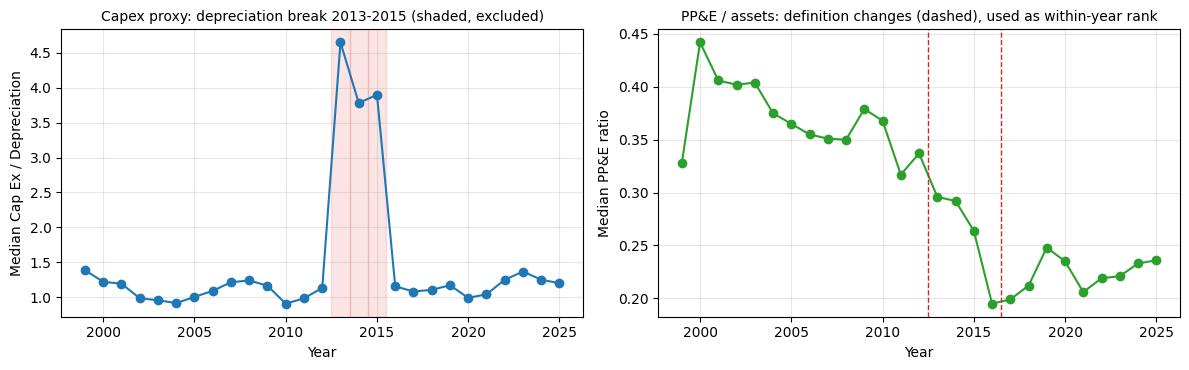

,payout,lev,lev_unadj,lev_book,debt_ebitda,roe,tax,capex_deprec,ppe_assets,div_to_fcfe,div_yield
year,,,,,,,,,,,
1999,0.247,0.163,0.179,0.456,1.514,0.134,0.376,1.385,0.328,0.516,0.010
2000,0.182,0.206,0.206,0.460,2.217,0.143,0.259,1.218,0.442,0.462,0.011
2001,0.122,0.213,0.211,0.442,1.474,0.123,0.244,1.191,0.406,0.148,0.005
2002,0.159,0.241,0.232,0.433,1.641,0.085,0.209,0.982,0.402,0.182,0.006
2003,0.291,0.195,0.195,0.430,2.296,0.106,0.225,0.954,0.404,0.258,0.009
2004,0.170,0.156,0.156,0.410,1.518,0.104,0.203,0.913,0.375,0.212,0.004
2005,0.261,0.161,0.161,0.374,1.872,0.135,0.192,1.002,0.365,0.267,0.010
2006,0.247,0.153,0.153,0.385,1.759,0.151,0.189,1.089,0.355,0.304,0.010
2007,0.234,0.149,0.149,0.380,1.777,0.156,0.186,1.212,0.351,0.148,0.012


In [6]:
chk_cols = ["payout", "lev", "lev_unadj", "lev_book", "debt_ebitda", "roe", "tax", "capex_deprec", "ppe_assets",
            "div_to_fcfe", "div_yield"]
yearly_medians = panel_prewin.groupby("year")[[c for c in chk_cols if c in panel_prewin]].median().round(3)
yearly_medians.to_csv(OUTDIR / "tab_data_check_yearly_medians.csv")
crossfile_agreement.round(3).to_csv(OUTDIR / "tab_data_check_crossfile.csv")
alignment_check.to_csv(OUTDIR / "tab_data_check_alignment.csv", index=False)
debt_ebitda_check.to_csv(OUTDIR / "tab_data_check_debt_ebitda.csv", index=False)
# stability of the industry ordering: Spearman correlation of PP&E / assets with the previous year
_w = panel_prewin.pivot_table(index="industry", columns="year", values="ppe_assets")
ppe_rank_stability = pd.Series({y: _w[y - 1].corr(_w[y], method="spearman") for y in _w.columns[1:]},
                               name="rank_corr_with_previous_year").round(3)
ppe_rank_stability.rename_axis("year").to_csv(OUTDIR / "tab_data_check_ppe_rank_stability.csv")
print("PP&E / assets, rank correlation with the previous year (reshuffles in 2013 and 2016):")
print(ppe_rank_stability.to_frame().T.to_string(), "\n")
print("Share of industries where divfund payout = divfcfe D/NI (±5%):")
print(crossfile_agreement.round(2).to_frame().T.to_string(), "\n")
print("Constructed vs reported Debt/EBITDA (non-financial industries, years where Damodaran reports it):")
print(debt_ebitda_check.to_string(index=False), "\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axes[0]
ax.plot(yearly_medians.index, yearly_medians["capex_deprec"], "o-", color="tab:blue")
for y in TANG_BREAK_YEARS:
    ax.axvspan(y - .5, y + .5, color="tab:red", alpha=.12)
ax.set_ylabel("Median Cap Ex / Depreciation"); ax.set_xlabel("Year")
ax.set_title("Capex proxy: depreciation break 2013-2015 (shaded, excluded)", fontsize=10)
ax = axes[1]
ax.plot(yearly_medians.index, yearly_medians["ppe_assets"], "o-", color="tab:green")
for y in PPE_DEF_CHANGES:
    ax.axvline(y - .5, color="tab:red", ls="--", lw=1)
ax.set_ylabel("Median PP&E ratio"); ax.set_xlabel("Year")
ax.set_title("PP&E / assets: definition changes (dashed), used as within-year rank", fontsize=10)
fig.tight_layout(); fig.savefig(OUTDIR / "fig_data_check_tangibility.png", dpi=150); plt.show()
yearly_medians

## 3 · FRED macro data & the interest-rate regime  <span style="color:gray">(§4.1, §4.3.3)</span>

In [7]:
FRED_SERIES = ["FEDFUNDS", "GS10", "BAA", "AAA", "GDPC1"]   # monthly, except GDPC1 (quarterly)

def load_fred_snapshot(path=FRED_SNAPSHOT):
    s = pd.read_csv(path, parse_dates=["date"])
    return s.pivot(index="date", columns="series_id", values="value")

def fetch_fred_live(start="1998-01-01"):
    from pandas_datareader import data as pdr
    return pdr.DataReader(FRED_SERIES, "fred", start, pd.Timestamp.today())

def annualise(wide):
    a = wide.resample("YE").mean(); a.index = a.index.year
    out = pd.DataFrame(index=a.index)
    out["ffr"] = a["FEDFUNDS"]                       # annual-average effective fed funds rate
    out["t10"] = a["GS10"]                           # annual-average 10y Treasury yield (monthly GS10)
    out["cred_spread"] = a["BAA"] - a["AAA"]         # Moody's BAA - AAA
    out["gdp_growth"] = a["GDPC1"].pct_change() * 100
    out["ffr_change"] = out["ffr"].diff(); out.index.name = "year"
    return out.reset_index()

if FRED_SOURCE == "live":
    try:
        wide = fetch_fred_live(); print("FRED: live download OK")
    except Exception as e:
        print("FRED live download failed:", e, "-> using the pinned snapshot")
        wide = load_fred_snapshot()
else:
    wide = load_fred_snapshot()
    print(f"FRED: pinned snapshot {FRED_SNAPSHOT} (set FRED_SOURCE='live' to refresh)")
macro = annualise(wide)

def add_regime(m):
    m = m.copy()
    m["high_rate"] = ((m["year"] >= 2022).astype(int) if HIGH_RATE_RULE == "post2022"
                      else (m["ffr"] >= FFR_THRESHOLD).astype(int))
    m["high_rate_post2022"] = (m["year"] >= 2022).astype(int)   # kept for robustness
    return m

macro = add_regime(macro)
# Restrict macro to the Damodaran data range (ffr_change is computed on the full series first, so 1999's
# year-on-year change is preserved). This drops any partial current year and the 1998 lead row.
macro = macro[(macro["year"] >= min(years)) & (macro["year"] <= max(years))].reset_index(drop=True)
panel = panel.merge(macro, on="year", how="left")
print("Regime:", HIGH_RATE_RULE, "| high-rate years:",
      sorted(macro.loc[macro.high_rate == 1, "year"].tolist()))
macro.tail(6)

FRED: pinned snapshot data/fred/fred_snapshot.csv (set FRED_SOURCE='live' to refresh)
Regime: threshold | high-rate years: [1999, 2000, 2001, 2005, 2006, 2007, 2023, 2024, 2025]


,year,ffr,t10,cred_spread,gdp_growth,ffr_change,high_rate,high_rate_post2022
21,2020,0.375833,0.894167,1.125833,-2.081378,-1.782500,0,0
22,2021,0.080000,1.442500,0.688333,6.152022,-0.295833,0,0
23,2022,1.683333,2.951667,0.997500,2.524215,1.603333,0,1
24,2023,5.024167,3.957500,1.050833,2.934361,3.340833,1,1
25,2024,5.143333,4.208333,0.709167,2.793187,0.119167,1,1
26,2025,4.212500,4.291667,0.645833,2.106338,-0.930833,1,1


## 4 · Variable definitions  <span style="color:gray">(§4.3)</span>

`payout` (Dividend Payout) · `div_to_fcfe` (Dividends/FCFE) · `div_yield` (dividends ÷ market cap, no earnings in it; used for the ROE check in §9) · `lev` (market D/(D+E), `wacc`) ·
alternative leverage (§9d): `lev_unadj` (market D/(D+E) without capitalised leases), `lev_book` (book D/(D+E)),
`debt_ebitda` (D/(D+E) ÷ EBITDA/EV = debt relative to cash flow) · `tangibility` (**PP&E / total assets**,
percentile rank within the year because the definition changes in 2013 and 2017; the capex-based proxies
Cap Ex/Depreciation, Net Cap Ex/Sales and Capital/Sales are robustness checks in §10) · industry controls `roe`, `tax`, `size`=log(Market Cap) ·
macro controls `gdp_growth`, `cred_spread` · regime `high_rate`, `ffr`, `ffr_change`.

**Note on macro variables.** Anything that varies only over time (the regime dummy, the fed funds rate, GDP growth,
the credit spread) is perfectly collinear with the year fixed effects. In the two-way FE models these enter only
through interactions with industry variables; `fit_panel` prints any regressor the fixed effects absorb. §9 adds an
industry-FE-only specification in which the macro controls and the regime level are estimated directly.

In [8]:
panel["size"] = np.log(panel["mktcap"].where(panel["mktcap"] > 0))
ANALYSIS_VARS = ["payout", "lev", "lev_unadj", "lev_book", "debt_ebitda", "roe", "tax", "size", "tangibility",
                 "gdp_growth", "cred_spread", "high_rate", "ffr", "ffr_change"]
print("Non-null counts:")
print(panel[[c for c in ANALYSIS_VARS if c in panel]].notna().sum().to_string())

Non-null counts:
payout         1920
lev            2103
lev_unadj      2116
lev_book       2099
debt_ebitda    2088
roe            2102
tax            2103
size           2116
tangibility    2116
gdp_growth     2116
cred_spread    2116
high_rate      2116
ffr            2116
ffr_change     2116


## 5 · Descriptive statistics  <span style="color:gray">(§4.4, §6.1)</span>

In [9]:
desc = panel[[c for c in ANALYSIS_VARS if c in panel]].describe().T
desc = desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(3)
desc.to_csv(OUTDIR / "tab_descriptives.csv")

# Overall / between / within standard deviation (Stata xtsum logic). The fixed-effects estimates are
# identified only from the WITHIN variation, which is much smaller than the raw ranges suggest.
def xtsum(df, cols, entity="industry"):
    rows = {}
    for c in cols:
        s = df[[entity, c]].dropna()
        if s.empty:
            continue
        m = s.groupby(entity)[c].transform("mean")
        rows[c] = {"sd_overall": s[c].std(), "sd_between": s.groupby(entity)[c].mean().std(),
                   "sd_within": (s[c] - m + s[c].mean()).std()}
    return pd.DataFrame(rows).T.round(3)

sd_decomp = xtsum(panel, ["payout", "lev", "roe", "tax", "size", "tangibility", "div_to_fcfe"])
sd_decomp.to_csv(OUTDIR / "tab_sd_decomposition.csv")
print("Overall / between / within SD:"); print(sd_decomp.to_string()); print()
desc

Overall / between / within SD:
             sd_overall  sd_between  sd_within
payout            0.372       0.221      0.309
lev               0.139       0.129      0.076
roe               0.128       0.078      0.106
tax               0.095       0.080      0.069
size              1.337       1.349      0.587
tangibility       0.289       0.285      0.093
div_to_fcfe       1.560       0.876      1.398



,count,mean,std,min,25%,50%,75%,max
payout,1920.0,0.365,0.372,0.000,0.155,0.279,0.447,2.580
lev,2103.0,0.238,0.139,0.022,0.135,0.211,0.322,0.638
lev_unadj,2116.0,0.230,0.135,0.022,0.131,0.201,0.310,0.634
lev_book,2099.0,0.448,0.161,0.109,0.335,0.448,0.560,0.849
debt_ebitda,2088.0,2.519,1.496,0.434,1.488,2.255,3.133,8.966
roe,2102.0,0.133,0.128,-0.364,0.077,0.135,0.192,0.508
tax,2103.0,0.155,0.095,0.006,0.081,0.140,0.217,0.421
size,2116.0,11.833,1.337,7.461,10.929,11.889,12.802,15.877
tangibility,2116.0,0.506,0.289,0.013,0.256,0.506,0.756,1.000
gdp_growth,2116.0,2.304,1.730,-2.576,1.819,2.524,2.946,6.152


In [10]:
corr_vars = [c for c in ["payout", "lev", "roe", "tax", "size", "tangibility",
                         "gdp_growth", "cred_spread", "ffr"] if c in panel and panel[c].notna().any()]
panel[corr_vars].corr().round(2)

,payout,lev,roe,tax,size,tangibility,gdp_growth,cred_spread,ffr
payout,1.00,0.16,-0.24,-0.24,0.04,0.15,0.01,-0.06,-0.06
lev,0.16,1.00,-0.17,-0.01,-0.37,0.33,-0.08,0.08,-0.09
roe,-0.24,-0.17,1.00,0.15,0.24,0.02,0.09,-0.05,0.02
tax,-0.24,-0.01,0.15,1.00,-0.17,0.09,0.08,0.11,0.22
size,0.04,-0.37,0.24,-0.17,1.00,-0.15,0.02,-0.11,-0.01
tangibility,0.15,0.33,0.02,0.09,-0.15,1.00,0.00,-0.00,0.00
gdp_growth,0.01,-0.08,0.09,0.08,0.02,0.00,1.00,-0.68,0.26
cred_spread,-0.06,0.08,-0.05,0.11,-0.11,-0.00,-0.68,1.00,-0.32
ffr,-0.06,-0.09,0.02,0.22,-0.01,0.00,0.26,-0.32,1.00


## 6 · Baseline panel regression  <span style="color:gray">(§5.2, §6.2)</span>

$$\text{payout}_{it}=\beta\,\text{lev}_{it}+\gamma' X_{it}+\alpha_i+\delta_t+\varepsilon_{it}$$

Industry & year fixed effects, SE clustered by industry. Substitution view → **β < 0**. $X$ = industry-level controls (ROE, tax rate, size); year-only macro variables are absorbed by $\delta_t$.

In [11]:
def fit_panel(df, depvar, regressors, entity=True, time=True, cluster_time=False, title="",
              cov="clustered", weights=None):
    """Panel OLS with industry/year effects. cov="clustered" (by industry, optionally also by year) or
    cov="kernel" (Driscoll-Kraay, robust to cross-sectional dependence); weights = column name or None."""
    d = df.dropna(subset=[depvar] + regressors + ([weights] if weights else [])).copy()
    ny = d["year"].nunique()
    print(f"=== {title} ===\nobs={len(d)}  industries={d['industry'].nunique()}  years={ny}")
    if ny < 3 or not HAVE_LM:
        if not HAVE_LM:
            print("linearmodels unavailable."); return None
        import statsmodels.formula.api as smf
        print("Short panel -> pooled OLS.\n")
        res = smf.ols(f"{depvar} ~ " + " + ".join(regressors), data=d).fit(cov_type="HC1")
        print(res.summary().tables[1]); return res
    import statsmodels.api as sm
    dd = d.set_index(["industry", "year"]); X = sm.add_constant(dd[regressors])
    mod = PanelOLS(dd[depvar], X, entity_effects=entity, time_effects=time, drop_absorbed=True,
                   weights=dd[weights] if weights else None)
    if cov == "kernel":
        res = mod.fit(cov_type="kernel", kernel="bartlett", bandwidth=DK_BANDWIDTH)
    else:
        res = mod.fit(cov_type="clustered", cluster_entity=True, cluster_time=cluster_time)
    print(res.summary.tables[1]); print(f"R2(within): {res.rsquared_within:.3f}")
    absorbed = [r for r in regressors if r not in res.params.index]
    if absorbed:
        print("Absorbed by the fixed effects (not estimable, dropped):", absorbed)
    return res

# Industry-level controls. Year-only macro controls would be absorbed by the year fixed effects, so they
# are used only in the industry-FE-only robustness specification (§9).
BASE_CONTROLS  = ["roe", "tax", "size"]
MACRO_CONTROLS = [c for c in ["gdp_growth", "cred_spread"] if panel[c].notna().any()]
res_base = fit_panel(panel, "payout", ["lev"] + BASE_CONTROLS,
                     title="Baseline: payout ~ leverage + controls (two-way FE)")

=== Baseline: payout ~ leverage + controls (two-way FE) ===
obs=1894  industries=141  years=27


                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.5657     0.2193     2.5795     0.0100      0.1356      0.9958
lev            0.2991     0.1403     2.1329     0.0331      0.0241      0.5742
roe           -1.5913     0.2058    -7.7317     0.0000     -1.9950     -1.1876
tax           -0.4797     0.1649    -2.9092     0.0037     -0.8031     -0.1563
size           0.0049     0.0187     0.2644     0.7915     -0.0317      0.0416
R2(within): 0.165


## 7 · Interaction with the rate regime — H1 & H2  <span style="color:gray">(§5.3, §6.3)</span>

$$\text{payout}_{it}=\beta_1\text{lev}_{it}+\beta_2(\text{lev}_{it}\times\text{HighRate}_t)+\gamma' X_{it}+\alpha_i+\delta_t+\varepsilon_{it}$$

ME of leverage: low-rate $=\beta_1$, high-rate $=\beta_1+\beta_2$. **H2 ⇔ $\beta_2<0$.**

In [12]:
def lincom(res, weights):
    p = res.params
    cov = pd.DataFrame(np.asarray(res.cov if hasattr(res, "cov") else res.cov_params()),
                       index=p.index, columns=p.index)
    w = pd.Series(0.0, index=p.index)
    for k, v in weights.items():
        if k in w: w[k] = v
    est = float(w @ p); se = float(np.sqrt(w.values @ cov.values @ w.values))
    return est, se, (est / se if se else np.nan)

panel["lev_x_high"] = panel["lev"] * panel["high_rate"]
res_int = fit_panel(panel, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS,
                    title="H1/H2: payout ~ lev + lev x HighRate + controls (two-way FE)")
if res_int is not None and "lev_x_high" in getattr(res_int, "params", {}):
    lo = lincom(res_int, {"lev": 1}); hi = lincom(res_int, {"lev": 1, "lev_x_high": 1})
    print("\nMarginal effect of leverage on payout:")
    print(f"  low-rate  (b1)    = {lo[0]:+.4f} (SE {lo[1]:.4f}, t {lo[2]:+.2f})")
    print(f"  high-rate (b1+b2) = {hi[0]:+.4f} (SE {hi[1]:.4f}, t {hi[2]:+.2f})")
    print(f"  interaction b2    = {res_int.params['lev_x_high']:+.4f}  <-- H2 (expect < 0)")

=== H1/H2: payout ~ lev + lev x HighRate + controls (two-way FE) ===
obs=1894  industries=141  years=27
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.5679     0.2177     2.6090     0.0092      0.1410      0.9948
lev            0.3144     0.1447     2.1721     0.0300      0.0305      0.5983
lev_x_high    -0.0406     0.1411    -0.2878     0.7735     -0.3174      0.2362
roe           -1.5905     0.2055    -7.7413     0.0000     -1.9934     -1.1875
tax           -0.4815     0.1668    -2.8877     0.0039     -0.8086     -0.1545
size           0.0047     0.0184     0.2552     0.7986     -0.0315      0.0409
R2(within): 0.166

Marginal effect of leverage on payout:
  low-rate  (b1)    = +0.3144 (SE 0.1447, t +2.17)
  high-rate (b1+b2) = +0.2738 (SE 0.1732, t +1.58)
  interaction b2    = -0.

=== Continuous regime: payout ~ lev + lev x FFR + controls (two-way FE) ===
obs=1894  industries=141  years=27


                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.5667     0.2175     2.6059     0.0092      0.1402      0.9932
lev            0.3076     0.1543     1.9933     0.0464      0.0049      0.6102
lev_x_ffr     -0.0034     0.0329    -0.1039     0.9173     -0.0679      0.0611
roe           -1.5909     0.2054    -7.7459     0.0000     -1.9937     -1.1880
tax           -0.4801     0.1657    -2.8982     0.0038     -0.8051     -0.1552
size           0.0048     0.0184     0.2620     0.7933     -0.0313      0.0410
R2(within): 0.165


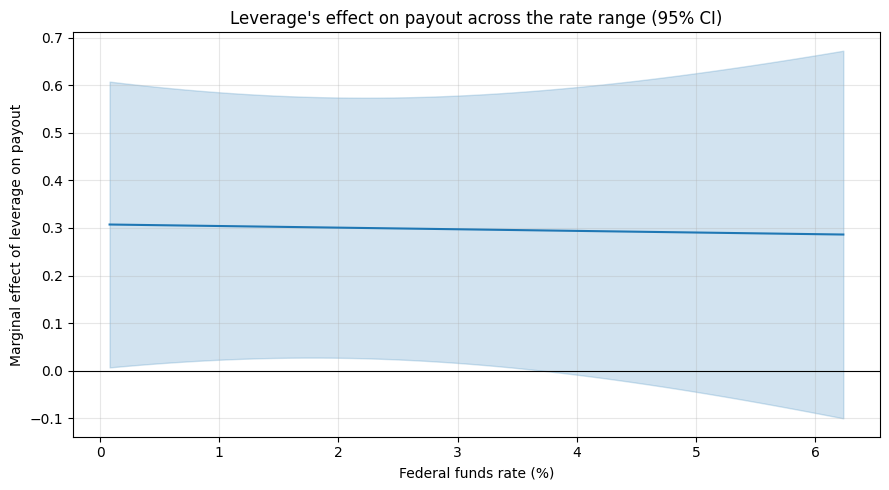

In [13]:
# continuous-regime variant + marginal-effect plot across the rate range
panel["lev_x_ffr"] = panel["lev"] * panel["ffr"]
res_cont = fit_panel(panel, "payout", ["lev", "lev_x_ffr"] + BASE_CONTROLS,
                     title="Continuous regime: payout ~ lev + lev x FFR + controls (two-way FE)")
if res_cont is not None and "lev_x_ffr" in getattr(res_cont, "params", {}):
    rr = np.linspace(panel["ffr"].min(), panel["ffr"].max(), 50)
    pts = [lincom(res_cont, {"lev": 1, "lev_x_ffr": r}) for r in rr]
    me = np.array([p[0] for p in pts]); se = np.array([p[1] for p in pts])
    plt.figure(); plt.plot(rr, me, color="tab:blue")
    plt.fill_between(rr, me - 1.96 * se, me + 1.96 * se, alpha=.2, color="tab:blue")
    plt.axhline(0, color="k", lw=.8)
    plt.xlabel("Federal funds rate (%)"); plt.ylabel("Marginal effect of leverage on payout")
    plt.title("Leverage's effect on payout across the rate range (95% CI)")
    plt.tight_layout(); plt.savefig(OUTDIR / "fig_marginal_effect.png", dpi=150); plt.show()

## 8 · Asset tangibility as a moderator — H3  <span style="color:gray">(§6.4)</span>

In [14]:
if panel["tangibility"].notna().any():
    panel["lev_x_tang"] = panel["lev"] * panel["tangibility"]
    panel["high_x_tang"] = panel["high_rate"] * panel["tangibility"]
    panel["lev_x_high_x_tang"] = panel["lev"] * panel["high_rate"] * panel["tangibility"]
    # A triple interaction needs every lower-order term, including the tangibility main effect.
    # (high_rate alone is absorbed by the year fixed effects.)
    H3_REGS = ["lev", "tangibility", "lev_x_high", "lev_x_tang", "high_x_tang", "lev_x_high_x_tang"]
    res_h3 = fit_panel(panel, "payout", H3_REGS + BASE_CONTROLS,
        title="H3: triple interaction lev x HighRate x tangibility (two-way FE)")

    # Variant: time-invariant industry tangibility (mean over non-break years) = a structural trait.
    # Its main effect is absorbed by the industry fixed effects; the interactions are identified.
    panel["tang_ind"] = panel.groupby("industry")["tangibility"].transform("mean")
    panel["lev_x_tangI"] = panel["lev"] * panel["tang_ind"]
    panel["high_x_tangI"] = panel["high_rate"] * panel["tang_ind"]
    panel["lev_x_high_x_tangI"] = panel["lev"] * panel["high_rate"] * panel["tang_ind"]
    H3I_REGS = ["lev", "tang_ind", "lev_x_high", "lev_x_tangI", "high_x_tangI", "lev_x_high_x_tangI"]
    res_h3_ti = fit_panel(panel, "payout", H3I_REGS + BASE_CONTROLS,
        title="H3 variant: time-invariant industry tangibility (two-way FE)")

    panel["tang_grp"] = pd.qcut(panel["tangibility"], 3, labels=["low", "mid", "high"], duplicates="drop")
    print("\n--- lev x HighRate by tangibility tercile ---")
    for g in ["low", "high"]:
        sub = panel[panel.tang_grp == g]
        if sub["year"].nunique() >= 3:
            fit_panel(sub, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS, title=f"Tangibility = {g}")
else:
    print("H3 inactive: no tangibility.")

=== H3: triple interaction lev x HighRate x tangibility (two-way FE) ===
obs=1894  industries=141  years=27
                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------
const                 0.5234     0.2106     2.4850     0.0130      0.1103      0.9365
lev                   0.3706     0.2569     1.4426     0.1493     -0.1333      0.8745
tangibility           0.1516     0.1403     1.0811     0.2798     -0.1235      0.4268
lev_x_high            0.5801     0.2668     2.1744     0.0298      0.0568      1.1033
lev_x_tang           -0.1668     0.5051    -0.3302     0.7413     -1.1575      0.8239
high_x_tang           0.1723     0.1099     1.5677     0.1171     -0.0433      0.3879
lev_x_high_x_tang    -1.0934     0.4948    -2.2097     0.0273     -2.0640     -0.1229
roe                  -1.6034    

                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
const                  0.5780     0.2057     2.8096     0.0050      0.1745      0.9814
lev                    0.6870     0.3192     2.1522     0.0315      0.0609      1.3130
lev_x_high             0.5464     0.2673     2.0444     0.0411      0.0222      1.0706
lev_x_tangI           -0.7205     0.6069    -1.1873     0.2353     -1.9108      0.4698
high_x_tangI           0.1206     0.1123     1.0745     0.2827     -0.0996      0.3408
lev_x_high_x_tangI    -1.0077     0.4976    -2.0252     0.0430     -1.9837     -0.0318
roe                   -1.5917     0.2061    -7.7230     0.0000     -1.9959     -1.1875
tax                   -0.4902     0.1643    -2.9830     0.0029     -0.8125     -0.1679
size                   0.0028     0.0172   


## 8b · Dividend smoothing: Lintner partial adjustment and H1 in change form  <span style="color:gray">(§6.4, §7.1)</span>

**Lintner (1956).** Firms move dividends only part of the way toward a target share of earnings each year:
$\Delta D_{it} = \text{SOA}\,(r\,E_{it} - D_{i,t-1})$. Scaling by last year's market cap (so large and small
industries are comparable) gives

$$\frac{\Delta D_{it}}{MC_{i,t-1}}=\beta_E\,\frac{E_{it}}{MC_{i,t-1}}+\beta_D\,\frac{D_{i,t-1}}{MC_{i,t-1}}+\alpha_i+\delta_t+\varepsilon_{it},
\qquad \text{SOA}=-\beta_D,\quad r=\beta_E/\text{SOA}.$$

A low speed of adjustment (SOA) means sticky dividends, the proposed explanation for the null in §7.

**H1 as stated is about changes** ("industries with higher leverage *reduce* dividends more during rate-hiking
cycles"). Adding last year's leverage and its interaction with the regime to the change equation tests it directly:
H1 ⇔ $\text{lev}_{t-1}\times\text{Regime}<0$. Three regime definitions: the high-rate dummy, hiking years
(fed funds up ≥ 25bp), and the continuous change in the fed funds rate.

**Estimation notes.** With a lagged dependent variable, industry fixed effects bias the persistence coefficient
downward (Nickell, 1981), so the within estimator *overstates* SOA, while pooled OLS without industry effects
*understates* it; the true value lies between the two (Bond, 2002). Dollar dividends and net income come from
`divfcfe` (net income excluded in the years flagged by the §2 cross-file check); industries merged by the rename
map are summed. Lags require the previous calendar year (no gap bridging), and 2013 is dropped from these models because
the 2012→2013 change crosses Damodaran's reclassification: industry dividends jump by a median 42% that year versus
10–20% in other years, which reflects firms moving between industries rather than dividend decisions.


In [15]:

# ---- dollar frame ($m): dividends & net income (divfcfe), market cap (divfund).
#      Industries merged by the rename map are SUMMED here (the ratio panel averages them).
usd = raw[["industry", "year", "div_usd", "ni_usd", "mktcap"]].copy()
usd["industry"] = usd["industry"].replace(INDUSTRY_RENAME)
usd = (usd[usd["industry"].isin(panel["industry"])]
       .groupby(["industry", "year"], as_index=False)[["div_usd", "ni_usd", "mktcap"]].sum(min_count=1))
L = usd.merge(panel[["industry", "year", "payout", "lev", "roe", "tax", "size",
                     "high_rate", "ffr_change", "in_core"]], on=["industry", "year"], how="inner")

# gap-safe one-year lags: an industry missing year t-1 gets no lag
_lag = L[["industry", "year", "div_usd", "mktcap", "lev", "payout"]].copy(); _lag["year"] += 1
L = L.merge(_lag.rename(columns={c: c + "_l1" for c in ["div_usd", "mktcap", "lev", "payout"]}),
            on=["industry", "year"], how="left")
L["dD"] = (L["div_usd"] - L["div_usd_l1"]) / L["mktcap_l1"]      # change in dividends
L["E"]  = L["ni_usd"] / L["mktcap_l1"]                            # current earnings
L["Dl"] = L["div_usd_l1"] / L["mktcap_l1"]                        # last year's dividends
L.loc[L["year"].isin(DIVFCFE_BAD_YEARS), ["dD", "E"]] = np.nan    # net income unreliable there (§2 check)
L.loc[L["year"] == RECLASS_YEAR, ["dD", "payout_l1", "lev_l1"]] = np.nan   # t-1 -> t crosses the 2013 reclassification
L = winsorize(L, ["dD", "E", "Dl"])
L["hike"] = (L["ffr_change"] >= HIKE_THRESHOLD).astype(int)
for a, b in [("E", "high_rate"), ("Dl", "high_rate"), ("lev_l1", "high_rate"),
             ("lev_l1", "hike"), ("lev_l1", "ffr_change")]:
    L[f"{a}_x_{b}"] = L[a] * L[b]
print("Hiking years (fed funds up >= %.2fpp):" % HIKE_THRESHOLD,
      sorted(int(y) for y in L.loc[L["hike"] == 1, "year"].unique()), "\n")

lint = {}
lint["L1_within"] = fit_panel(L, "dD", ["E", "Dl"], title="L1 Lintner, two-way FE (SOA upper bound)")
lint["L1_pooled"] = fit_panel(L, "dD", ["E", "Dl"], entity=False,
                              title="L1 Lintner, year FE only (SOA lower bound)")
lint["L2_regime"] = fit_panel(L, "dD", ["E", "Dl", "E_x_high_rate", "Dl_x_high_rate"],
                              title="L2 Smoothing by regime")
H1C = ["E", "Dl", "lev_l1"]
lint["L3_high"]  = fit_panel(L, "dD", H1C + ["lev_l1_x_high_rate"], title="L3 H1 in change form: high-rate years")
lint["L3_hike"]  = fit_panel(L, "dD", H1C + ["lev_l1_x_hike"], title="L3 H1 in change form: hiking years")
lint["L3_dffr"]  = fit_panel(L, "dD", H1C + ["lev_l1_x_ffr_change"], title="L3 H1 in change form: change in FFR")
lint["L3_core"]  = fit_panel(L[L["in_core"]], "dD", H1C + ["lev_l1_x_high_rate"],
                             title="L3 H1 in change form: high-rate years, stable core")
lint["R_within"] = fit_panel(L, "payout", ["payout_l1"] + BASE_CONTROLS, title="Payout-ratio persistence, two-way FE")
lint["R_pooled"] = fit_panel(L, "payout", ["payout_l1"] + BASE_CONTROLS, entity=False,
                             title="Payout-ratio persistence, year FE only")

# ---- summary
soa_hi, soa_lo = -lint["L1_within"].params["Dl"], -lint["L1_pooled"].params["Dl"]
target = lint["L1_pooled"].params["E"] / soa_lo
rho_lo, rho_hi = lint["R_within"].params["payout_l1"], lint["R_pooled"].params["payout_l1"]
print(f"\nSpeed of adjustment of dividends: between {soa_lo:.2f} and {soa_hi:.2f} per year "
      f"(dividend persistence {1 - soa_hi:.2f}-{1 - soa_lo:.2f}); target payout (pooled) = {target:.2f}")
print(f"Persistence of the payout RATIO: {rho_lo:.2f}-{rho_hi:.2f}")

KEYS = [("L1_within", "Dl", "Lintner, two-way FE"), ("L1_pooled", "Dl", "Lintner, year FE only"),
        ("L2_regime", "Dl_x_high_rate", "Smoothing x high-rate"), ("L2_regime", "E_x_high_rate", "Earnings x high-rate"),
        ("L3_high", "lev_l1_x_high_rate", "H1 change form: high-rate"),
        ("L3_hike", "lev_l1_x_hike", "H1 change form: hiking year"),
        ("L3_dffr", "lev_l1_x_ffr_change", "H1 change form: change in FFR"),
        ("L3_core", "lev_l1_x_high_rate", "H1 change form: high-rate, stable core"),
        ("R_within", "payout_l1", "Payout-ratio persistence, two-way FE"),
        ("R_pooled", "payout_l1", "Payout-ratio persistence, year FE only")]
lint_tbl = pd.DataFrame([{"model": lab, "term": t, "coef": lint[k].params[t], "se": lint[k].std_errors[t],
                          "p": lint[k].pvalues[t], "N": int(lint[k].nobs)} for k, t, lab in KEYS]).round(4)
lint_tbl.to_csv(OUTDIR / "tab_lintner.csv", index=False)
lint_tbl


Hiking years (fed funds up >= 0.25pp): [2000, 2005, 2006, 2016, 2017, 2018, 2019, 2022, 2023] 

=== L1 Lintner, two-way FE (SOA upper bound) ===
obs=1771  industries=131  years=23
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.0050     0.0005     10.518     0.0000      0.0040      0.0059
E              0.0259     0.0066     3.8983     0.0001      0.0129      0.0389
Dl            -0.3624     0.0278    -13.012     0.0000     -0.4170     -0.3077
R2(within): 0.162
=== L1 Lintner, year FE only (SOA lower bound) ===
obs=1771  industries=131  years=23
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const

                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
const              0.0050     0.0005     10.623     0.0000      0.0041      0.0060
E                  0.0244     0.0076     3.2021     0.0014      0.0095      0.0394
Dl                -0.3744     0.0293    -12.780     0.0000     -0.4319     -0.3170
E_x_high_rate      0.0044     0.0123     0.3557     0.7221     -0.0197      0.0285
Dl_x_high_rate     0.0336     0.0391     0.8594     0.3903     -0.0431      0.1102
R2(within): 0.155
=== L3 H1 in change form: high-rate years ===
obs=1771  industries=131  years=23
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
---------------------------------------------------------------

                                  Parameter Estimates                                  
                     Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
---------------------------------------------------------------------------------------
const                   0.0039     0.0007     5.4407     0.0000      0.0025      0.0052
E                       0.0274     0.0065     4.2278     0.0000      0.0147      0.0401
Dl                     -0.3816     0.0310    -12.314     0.0000     -0.4424     -0.3209
lev_l1                  0.0054     0.0029     1.8464     0.0650     -0.0003      0.0112
lev_l1_x_ffr_change     0.0006     0.0009     0.6468     0.5179     -0.0011      0.0023
R2(within): 0.169
=== L3 H1 in change form: high-rate years, stable core ===
obs=1026  industries=46  years=23
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------

,model,term,coef,se,p,N
0,"Lintner, two-way FE",Dl,-0.3624,0.0278,0.0000,1771
1,"Lintner, year FE only",Dl,-0.0943,0.0270,0.0005,1771
2,Smoothing x high-rate,Dl_x_high_rate,0.0336,0.0391,0.3903,1771
3,Earnings x high-rate,E_x_high_rate,0.0044,0.0123,0.7221,1771
4,H1 change form: high-rate,lev_l1_x_high_rate,0.0016,0.0039,0.6751,1771
5,H1 change form: hiking year,lev_l1_x_hike,0.0015,0.0023,0.5050,1771
6,H1 change form: change in FFR,lev_l1_x_ffr_change,0.0006,0.0009,0.5179,1771
7,"H1 change form: high-rate, stable core",lev_l1_x_high_rate,0.0022,0.0030,0.4647,1026
8,"Payout-ratio persistence, two-way FE",payout_l1,0.1320,0.0438,0.0026,1651
9,"Payout-ratio persistence, year FE only",payout_l1,0.4263,0.0553,0.0000,1651


## 9 · Robustness  <span style="color:gray">(§5.5, §6.5)</span>

Alt payout measures · **stable-core sample** (immune to the 2013 reclassification) · **post-2022 regime**
definition · two-way clustering · ex-COVID · lagged leverage · **industry FE only with macro controls** ·
**ROE mechanical-link check (dividend yield as an earnings-free DV)** · **backward elimination of insignificant controls** · **H3 in the stable core** · **payout as reported (incl. non-positive earnings)** · **Driscoll–Kraay SE** · **first differences** ·
**weighting by number of firms** (the last three also stress-test the leverage coefficient, §9c) ·
**alternative leverage measures**: without leases, book, Debt/EBITDA (§9d) · **H3 sensitivity** (inference,
sample, continuous rate).

In [16]:
robust = {}
# (a) stable core
print(">>> Stable core (industries present >= MIN_YEARS_CORE years)")
robust["core"] = fit_panel(panel[panel.in_core], "payout", ["lev", "lev_x_high"] + BASE_CONTROLS,
                           title=f"Stable core ({len(CORE)} industries)")
# (b) post-2022 regime definition
pp = panel.copy(); pp["lev_x_high"] = pp["lev"] * pp["high_rate_post2022"]
print("\n>>> Post-2022 binary regime")
robust["post2022"] = fit_panel(pp, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS,
                               title="Regime = post-2022 binary")
# (c) alternative payout
for dv_alt in ["div_to_fcfe", "totpayout_ni", "div_yield"]:
    if dv_alt in panel and panel[dv_alt].notna().any():
        print(f"\n>>> Alt payout: {dv_alt}")
        robust[dv_alt] = fit_panel(panel, dv_alt, ["lev", "lev_x_high"] + BASE_CONTROLS, title=f"DV={dv_alt}")
# (d) two-way clustering
print("\n>>> Two-way clustered SE")
robust["twoway"] = fit_panel(panel, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS,
                             cluster_time=True, title="Two-way clustering")
# (e) ex-COVID
print("\n>>> Excluding COVID years", COVID_YEARS)
robust["noCovid"] = fit_panel(panel[~panel.year.isin(COVID_YEARS)], "payout",
                              ["lev", "lev_x_high"] + BASE_CONTROLS, title="Excl. COVID")
# (f) lagged leverage
pl = panel.sort_values(["industry", "year"]).copy()
pl["lev_lag"] = pl.groupby("industry")["lev"].shift(1)
pl["lev_lag_x_high"] = pl["lev_lag"] * pl["high_rate"]
if pl["lev_lag"].notna().any():
    print("\n>>> Lagged leverage")
    robust["lagged"] = fit_panel(pl, "payout", ["lev_lag", "lev_lag_x_high"] + BASE_CONTROLS,
                                 title="Lagged leverage")

# (g) industry FE only: the macro controls and the regime level are estimable here (no year FE),
#     so errors are clustered by industry AND year.
print("\n>>> Industry FE only, with macro controls and the regime level")
robust["indFE_macro"] = fit_panel(panel, "payout",
    ["lev", "high_rate", "lev_x_high"] + BASE_CONTROLS + MACRO_CONTROLS,
    time=False, cluster_time=True, title="Industry FE + macro controls (no year FE), two-way clustered")

# (h) ROE mechanical-link check. The payout ratio is D/NI and ROE is NI/E, so both contain net income.
#     Dividends/FCFE does not solve this (FCFE = NI - net capex - change in working capital + net borrowing).
#     Dividend yield (D / market cap) contains no earnings, so the ROE coefficient there is free of the
#     accounting link. Caveat: yield and leverage D/(D+E) both contain market equity, so the LEVERAGE
#     coefficient in the yield regression is itself partly mechanical; the check is about ROE only.
print("\n>>> ROE mechanical-link check: interaction model without ROE")
robust["noROE"] = fit_panel(panel, "payout", ["lev", "lev_x_high", "tax", "size"],
                            title="Interaction without ROE")
_roe_rows = []
for dv_, res_, ni_in in [("payout (D/NI)", res_int, "yes"), ("Dividends/FCFE", robust.get("div_to_fcfe"), "yes (via FCFE)"),
                         ("Dividend yield (D/MC)", robust.get("div_yield"), "no")]:
    if res_ is not None and "roe" in res_.params:
        _roe_rows.append({"dependent variable": dv_, "net income in DV": ni_in, "roe_coef": res_.params["roe"],
                          "se": res_.std_errors["roe"], "p": res_.pvalues["roe"], "N": int(res_.nobs)})
roe_check = pd.DataFrame(_roe_rows).round(4)
roe_check.to_csv(OUTDIR / "tab_roe_check.csv", index=False)
print("\nROE coefficient by dependent variable (interaction model, two-way FE):")
print(roe_check.to_string(index=False))

# (i) Backward elimination a posteriori: repeatedly drop the least significant CONTROL with p > 0.05.
#     The hypothesis terms (lev, lev_x_high) are never dropped.
print("\n>>> Backward elimination of insignificant controls (a posteriori, 5%)")
keep = list(BASE_CONTROLS)
while keep:
    r_ = fit_panel(panel, "payout", ["lev", "lev_x_high"] + keep, title=f"Elimination step: controls={keep}")
    pv = r_.pvalues[keep]
    if pv.max() <= 0.05:
        break
    print(f"   -> dropping {pv.idxmax()} (p={pv.max():.3f})\n")
    keep.remove(pv.idxmax())
robust["elimination"] = r_
print("Controls retained by elimination:", keep)

# (j) H3 in the stable core
if "res_h3" in globals():
    print("\n>>> H3 in the stable core")
    robust["H3_core"] = fit_panel(panel[panel.in_core], "payout", H3_REGS + BASE_CONTROLS,
                                  title="H3: stable core")

# (k) payout as reported, including industry-years with non-positive earnings
print("\n>>> Payout as reported, including industry-years with ROE <= 0")
robust["payout_all"] = fit_panel(panel, "payout_all", ["lev", "lev_x_high"] + BASE_CONTROLS,
                                 title="DV = payout as reported (incl. ROE <= 0)")

# ---- Stress tests of the leverage-payout relation and of H2 (§9c). For each, the baseline model gives the
#      leverage coefficient and the interaction model gives beta2.
stress_base = {"main": res_base}
# (l) Driscoll-Kraay SE: robust to cross-sectional dependence (common shocks hit all industries in a year)
#     and to serial correlation up to DK_BANDWIDTH lags.
print("\n>>> Driscoll-Kraay standard errors")
stress_base["dk"] = fit_panel(panel, "payout", ["lev"] + BASE_CONTROLS, cov="kernel",
                              title="Baseline, Driscoll-Kraay SE")
robust["dk"] = fit_panel(panel, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS, cov="kernel",
                         title="Interaction, Driscoll-Kraay SE")
stress_base["twoway"] = fit_panel(panel, "payout", ["lev"] + BASE_CONTROLS, cluster_time=True,
                                  title="Baseline, two-way clustered SE")

# (m) First differences: eliminate the industry effects by differencing instead of demeaning. Gap-safe
#     (previous calendar year only), with year effects; 2013 dropped (the change crosses the reclassification).
_s = panel.sort_values(["industry", "year"])
_g = _s.groupby("industry")
_consec = _g["year"].shift(1) == _s["year"] - 1
fd = _s[["industry", "year", "in_core"]].copy()
for v in ["payout", "lev", "lev_x_high"] + BASE_CONTROLS:
    fd["d_" + v] = (_s[v] - _g[v].shift(1)).where(_consec)
fd.loc[fd["year"] == RECLASS_YEAR, [c for c in fd.columns if c.startswith("d_")]] = np.nan
D_CONTROLS = ["d_" + c for c in BASE_CONTROLS]
print("\n>>> First differences (with year effects)")
stress_base["fd"] = fit_panel(fd, "d_payout", ["d_lev"] + D_CONTROLS, entity=False,
                              title="Baseline, first differences")
robust["fd"] = fit_panel(fd, "d_payout", ["d_lev", "d_lev_x_high"] + D_CONTROLS, entity=False,
                         title="Interaction, first differences")

# (n) Weighted by the number of firms in the industry (large industries count more)
print("\n>>> Weighted by number of firms")
stress_base["wls"] = fit_panel(panel, "payout", ["lev"] + BASE_CONTROLS, weights="n_firms",
                               title="Baseline, weighted by number of firms")
robust["wls"] = fit_panel(panel, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS, weights="n_firms",
                          title="Interaction, weighted by number of firms")

# (o) Alternative leverage measures (§9d). Each replaces `lev` in the baseline and interaction models; `m_x_high`
#     is the measure times the high-rate dummy. Debt/EBITDA is also interacted with the fed funds rate: with year
#     effects, FFR x Debt/EBITDA is the part of an interest-burden proxy (rate x debt / cash flow) that differs
#     across industries. Caveat: Debt/EBITDA and the payout ratio both contain earnings, so the dividend yield
#     (no earnings in it) is reported as a second dependent variable.
ALT_LEV = {"lev": "Market D/(D+E), main (leases from 2013)", "lev_unadj": "Market D/(D+E), without leases",
           "lev_book": "Book D/(D+E)", "debt_ebitda": "Debt / EBITDA"}
alt_base, alt_int = {}, {}
for v, lab in ALT_LEV.items():
    d = panel.assign(m_x_high=panel[v] * panel["high_rate"], m_x_ffr=panel[v] * panel["ffr"])
    print(f"\n>>> Leverage measure: {lab}")
    alt_base[v] = fit_panel(d, "payout", [v] + BASE_CONTROLS, title=f"Baseline, leverage = {lab}")
    alt_int[v] = fit_panel(d, "payout", [v, "m_x_high"] + BASE_CONTROLS, title=f"Interaction, leverage = {lab}")
    if v != "lev":
        robust[v] = alt_int[v]
    if v == "debt_ebitda":
        alt_int["debt_ebitda_ffr"] = fit_panel(d, "payout", [v, "m_x_ffr"] + BASE_CONTROLS,
                                               title="Debt/EBITDA x fed funds rate (interest-burden proxy)")
        alt_base["debt_ebitda_yield"] = fit_panel(d, "div_yield", [v] + BASE_CONTROLS,
                                                  title="DV = dividend yield, baseline, Debt/EBITDA")
        alt_int["debt_ebitda_yield"] = fit_panel(d, "div_yield", [v, "m_x_high"] + BASE_CONTROLS,
                                                 title="DV = dividend yield, Debt/EBITDA x high-rate")

# (p) Sensitivity of the H3 triple term (primary tangibility measure) to inference, sample and regime definition
if "res_h3" in globals():
    H3M = H3_REGS + BASE_CONTROLS
    print("\n>>> H3 sensitivity")
    h3_rob = {"Main (industry-clustered SE)": res_h3,
              "Driscoll-Kraay SE": fit_panel(panel, "payout", H3M, cov="kernel", title="H3, Driscoll-Kraay SE"),
              "Two-way clustered SE": fit_panel(panel, "payout", H3M, cluster_time=True, title="H3, two-way clustered SE"),
              "Excl. 2020-21": fit_panel(panel[~panel.year.isin(COVID_YEARS)], "payout", H3M, title="H3, excl. COVID"),
              "Weighted by number of firms": fit_panel(panel, "payout", H3M, weights="n_firms", title="H3, weighted"),
              "Stable core": robust.get("H3_core")}
    _c = panel.assign(lev_x_high=panel.lev * panel.ffr, high_x_tang=panel.ffr * panel.tangibility,
                      lev_x_high_x_tang=panel.lev * panel.ffr * panel.tangibility)
    h3_rob["Continuous rate (FFR, per pp)"] = fit_panel(_c, "payout", H3M, title="H3 with the fed funds rate")
    h3_rob_tbl = pd.DataFrame([{"specification": k, "triple_coef": r.params["lev_x_high_x_tang"],
                                "se": r.std_errors["lev_x_high_x_tang"], "p": r.pvalues["lev_x_high_x_tang"],
                                "N": int(r.nobs)} for k, r in h3_rob.items() if r is not None]).round(4)
    h3_rob_tbl.to_csv(OUTDIR / "tab_H3_robustness.csv", index=False)
    print("\nH3 triple term across specifications:"); print(h3_rob_tbl.to_string(index=False))


>>> Stable core (industries present >= MIN_YEARS_CORE years)
=== Stable core (46 industries) ===
obs=1089  industries=46  years=27
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.5958     0.2741     2.1737     0.0300      0.0579      1.1336
lev            0.4767     0.1505     3.1663     0.0016      0.1813      0.7721
lev_x_high    -0.0887     0.1759    -0.5044     0.6141     -0.4340      0.2565
roe           -1.5741     0.2521    -6.2429     0.0000     -2.0689     -1.0793
tax           -0.4616     0.1957    -2.3589     0.0185     -0.8456     -0.0776
size           0.0024     0.0230     0.1055     0.9160     -0.0427      0.0476
R2(within): 0.177

>>> Post-2022 binary regime
=== Regime = post-2022 binary ===
obs=1894  industries=141  years=27
                             Parameter Est

                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.9918     1.2741     0.7784     0.4365     -1.5075      3.4911
lev            1.0065     0.7343     1.3707     0.1707     -0.4339      2.4468
lev_x_high    -0.2618     0.6567    -0.3986     0.6903     -1.5500      1.0265
roe           -2.8535     0.7815    -3.6513     0.0003     -4.3865     -1.3205
tax           -1.6625     1.7121    -0.9710     0.3317     -5.0209      1.6960
size           0.0191     0.1012     0.1882     0.8508     -0.1795      0.2176
R2(within): 0.043

>>> Alt payout: totpayout_ni
=== DV=totpayout_ni ===
obs=894  industries=91  years=13
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------

                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.5679     0.1953     2.9084     0.0037      0.1849      0.9509
lev            0.3144     0.1477     2.1283     0.0335      0.0247      0.6042
lev_x_high    -0.0406     0.1374    -0.2956     0.7676     -0.3102      0.2289
roe           -1.5905     0.2108    -7.5443     0.0000     -2.0040     -1.1770
tax           -0.4815     0.1523    -3.1615     0.0016     -0.7803     -0.1828
size           0.0047     0.0159     0.2961     0.7672     -0.0265      0.0359
R2(within): 0.166

>>> Excluding COVID years [2020, 2021]
=== Excl. COVID ===
obs=1771  industries=141  years=25
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------

=== Industry FE + macro controls (no year FE), two-way clustered ===
obs=1894  industries=141  years=27
                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------
const           0.6402     0.2525     2.5359     0.0113      0.1450      1.1354
lev             0.3871     0.1608     2.4068     0.0162      0.0717      0.7026
high_rate       0.0165     0.0479     0.3449     0.7302     -0.0774      0.1104
lev_x_high     -0.1444     0.1564    -0.9231     0.3561     -0.4511      0.1624
roe            -1.4650     0.1951    -7.5073     0.0000     -1.8478     -1.0823
tax            -1.2713     0.2855    -4.4536     0.0000     -1.8312     -0.7114
size            0.0081     0.0185     0.4379     0.6615     -0.0282      0.0444
gdp_growth      0.0074     0.0116     0.6376     0.5238     -0.0153      0.0301
cred_spread    -

=== Elimination step: controls=['roe', 'tax', 'size'] ===
obs=1894  industries=141  years=27
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.5679     0.2177     2.6090     0.0092      0.1410      0.9948
lev            0.3144     0.1447     2.1721     0.0300      0.0305      0.5983
lev_x_high    -0.0406     0.1411    -0.2878     0.7735     -0.3174      0.2362
roe           -1.5905     0.2055    -7.7413     0.0000     -1.9934     -1.1875
tax           -0.4815     0.1668    -2.8877     0.0039     -0.8086     -0.1545
size           0.0047     0.0184     0.2552     0.7986     -0.0315      0.0409
R2(within): 0.166
   -> dropping size (p=0.799)

=== Elimination step: controls=['roe', 'tax'] ===
obs=1894  industries=141  years=27


...

                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------
const           0.6422     0.2492     2.5772     0.0100      0.1535      1.1308
debt_ebitda     0.0491     0.0167     2.9370     0.0034      0.0163      0.0820
roe            -1.4838     0.1967    -7.5450     0.0000     -1.8696     -1.0981
tax            -0.3872     0.1618    -2.3934     0.0168     -0.7044     -0.0699
size           -0.0080     0.0205    -0.3916     0.6954     -0.0484      0.0323
R2(within): 0.193
=== Interaction, leverage = Debt / EBITDA ===
obs=1891  industries=141  years=27
                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------
const           0.645

                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------
const           0.6418     0.2457     2.6120     0.0091      0.1599      1.1237
debt_ebitda     0.0489     0.0182     2.6916     0.0072      0.0133      0.0846
m_x_ffr         0.0001     0.0037     0.0340     0.9729     -0.0072      0.0074
roe            -1.4839     0.1966    -7.5459     0.0000     -1.8696     -1.0982
tax            -0.3870     0.1619    -2.3896     0.0170     -0.7046     -0.0694
size           -0.0080     0.0204    -0.3941     0.6935     -0.0480      0.0319
R2(within): 0.193
=== DV = dividend yield, baseline, Debt/EBITDA ===
obs=2073  industries=141  years=27
                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------

                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------
const           0.0487     0.0085     5.7472     0.0000      0.0321      0.0653
debt_ebitda -6.804e-05     0.0003    -0.1965     0.8442     -0.0007      0.0006
m_x_high        0.0001     0.0005     0.2064     0.8365     -0.0009      0.0011
roe         -8.174e-05     0.0023    -0.0351     0.9720     -0.0046      0.0045
tax            -0.0002     0.0041    -0.0500     0.9602     -0.0082      0.0078
size           -0.0029     0.0007    -4.0307     0.0001     -0.0043     -0.0015
R2(within): 0.063

>>> H3 sensitivity
=== H3, Driscoll-Kraay SE ===
obs=1894  industries=141  years=27
                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----

                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------
const                 0.5234     0.1818     2.8790     0.0040      0.1668      0.8800
lev                   0.3706     0.2267     1.6350     0.1022     -0.0740      0.8153
tangibility           0.1516     0.1524     0.9949     0.3199     -0.1473      0.4506
lev_x_high            0.5801     0.3186     1.8206     0.0688     -0.0448      1.2050
lev_x_tang           -0.1668     0.4814    -0.3465     0.7290     -1.1109      0.7774
high_x_tang           0.1723     0.0990     1.7399     0.0821     -0.0219      0.3665
lev_x_high_x_tang    -1.0934     0.4814    -2.2712     0.0233     -2.0377     -0.1492
roe                  -1.6034     0.2048    -7.8280     0.0000     -2.0051     -1.2016
tax                  -0.4877     0.1554    -3.1386    

                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------
const                 0.7235     0.3101     2.3329     0.0198      0.1152      1.3318
lev                   0.5801     0.2468     2.3500     0.0189      0.0959      1.0642
tangibility           0.1037     0.1683     0.6163     0.5378     -0.2263      0.4337
lev_x_high            0.3952     0.1854     2.1318     0.0332      0.0316      0.7589
lev_x_tang           -0.4933     0.6103    -0.8082     0.4191     -1.6903      0.7038
high_x_tang           0.1360     0.1107     1.2288     0.2193     -0.0811      0.3530
lev_x_high_x_tang    -0.9047     0.4196    -2.1563     0.0312     -1.7276     -0.0818
roe                  -1.7630     0.2494    -7.0690     0.0000     -2.2521     -1.2738
tax                  -0.5303     0.2031    -2.6104    

In [17]:

# Robustness summary (Appendix C): the regime-interaction term in every specification
KEY = {"lagged": "lev_lag_x_high", "H3_core": "lev_x_high_x_tang", "fd": "d_lev_x_high",
       "lev_unadj": "m_x_high", "lev_book": "m_x_high", "debt_ebitda": "m_x_high"}
LABEL = {"core": "Stable core", "post2022": "Regime = post-2022", "div_to_fcfe": "DV = Dividends/FCFE",
         "totpayout_ni": "DV = (Div+Buybacks)/NI", "div_yield": "DV = Dividend yield", "twoway": "Two-way clustered SE", "noCovid": "Excl. 2020-21",
         "lagged": "Lagged leverage", "indFE_macro": "Industry FE + macro controls",
         "noROE": "Without ROE", "elimination": "Backward elimination",
         "payout_all": "Payout incl. non-positive earnings", "dk": "Driscoll-Kraay SE",
         "fd": "First differences", "wls": "Weighted by number of firms",
         "lev_unadj": "Leverage without leases", "lev_book": "Book leverage",
         "debt_ebitda": "Debt/EBITDA (per unit, not per SD)", "H3_core": "H3 triple term, stable core"}
rows = [{"specification": "Main (two-way FE)", "term": "lev_x_high",
         "coef": res_int.params["lev_x_high"], "se": res_int.std_errors["lev_x_high"],
         "p": res_int.pvalues["lev_x_high"], "N": int(res_int.nobs)}]
for k, r in robust.items():
    if r is None:
        continue
    term = KEY.get(k, "lev_x_high")
    if term in r.params:
        rows.append({"specification": LABEL.get(k, k), "term": term, "coef": r.params[term],
                     "se": r.std_errors[term], "p": r.pvalues[term], "N": int(r.nobs)})
rob_tbl = pd.DataFrame(rows).round(4)
rob_tbl.to_csv(OUTDIR / "tab_robustness_summary.csv", index=False)
rob_tbl


,specification,term,coef,se,p,N
0,Main (two-way FE),lev_x_high,-0.0406,0.1411,0.7735,1894
1,Stable core,lev_x_high,-0.0887,0.1759,0.6141,1089
2,Regime = post-2022,lev_x_high,-0.1658,0.2647,0.5312,1894
3,DV = Dividends/FCFE,lev_x_high,-0.2618,0.6567,0.6903,1602
4,DV = (Div+Buybacks)/NI,lev_x_high,-0.4497,1.0514,0.6690,894
5,DV = Dividend yield,lev_x_high,0.0066,0.0042,0.1176,2087
6,Two-way clustered SE,lev_x_high,-0.0406,0.1374,0.7676,1894
7,Excl. 2020-21,lev_x_high,-0.0684,0.1491,0.6464,1771
8,Lagged leverage,lev_lag_x_high,-0.0431,0.1604,0.7885,1764
9,Industry FE + macro controls,lev_x_high,-0.1444,0.1564,0.3561,1894


### 9b · How large an effect can we rule out?  <span style="color:gray">(§6.5, §7.1)</span>

A non-significant estimate is only informative if the test could have detected an effect of economically
relevant size. For the H2 interaction in each payout-ratio specification the table reports:

- the **95% confidence interval** of β₂: regime effects outside it are rejected at 5%;
- the **minimum detectable effect** at 5% significance and 80% power, MDE = (z₀.₉₇₅ + z₀.₈₀)·SE ≈ 2.8·SE
  (Bloom, 1995): the smallest true β₂ the test would detect four times out of five;
- the smallest **equivalence margin** δ for which two one-sided tests (TOST; Schuirmann, 1987; Lakens, 2017)
  reject |β₂| ≥ δ at 5%, i.e. the largest absolute bound of the 90% interval.

Coefficients are converted into payout-ratio units for a one-standard-deviation difference in leverage
(overall SD, i.e. across industries, as H2 compares more and less levered industries; the within-industry SD
is shown for reference). `EQUIV_MARGIN` in the configuration sets the effect regarded as economically
negligible for the yes/no equivalence column.

In [18]:
from scipy import stats
Z95, Z90, Z80 = stats.norm.ppf(0.975), stats.norm.ppf(0.95), stats.norm.ppf(0.80)
SD_LEV   = float(sd_decomp.loc["lev", "sd_overall"])   # across industries (used for the payout conversion)
SD_LEV_W = float(sd_decomp.loc["lev", "sd_within"])    # within industries (reference)
MEAN_PAYOUT = float(panel["payout"].mean())

PAYOUT_SPECS = ["Main (two-way FE)", "Stable core", "Regime = post-2022", "Two-way clustered SE",
                "Excl. 2020-21", "Lagged leverage", "Industry FE + macro controls", "Without ROE",
                "Backward elimination", "Payout incl. non-positive earnings", "Driscoll-Kraay SE",
                "First differences", "Weighted by number of firms"]
pw = rob_tbl[rob_tbl["specification"].isin(PAYOUT_SPECS)][["specification", "coef", "se", "N"]].copy()
lo95, hi95 = pw["coef"] - Z95 * pw["se"], pw["coef"] + Z95 * pw["se"]
pw["ci95"] = [f"[{a:+.3f}, {b:+.3f}]" for a, b in zip(lo95, hi95)]
pw["mde80"] = (Z95 + Z80) * pw["se"]                                    # Bloom (1995)
pw["tost_margin"] = np.maximum((pw["coef"] - Z90 * pw["se"]).abs(), (pw["coef"] + Z90 * pw["se"]).abs())
pw["ci95_bound_payout"] = np.maximum(lo95.abs(), hi95.abs()) * SD_LEV   # largest effect not rejected
pw["mde80_payout"] = pw["mde80"] * SD_LEV
pw["tost_margin_payout"] = pw["tost_margin"] * SD_LEV
pw["ci95_bound_payout_within"] = np.maximum(lo95.abs(), hi95.abs()) * SD_LEV_W
pw["equivalent_at_margin"] = pw["tost_margin_payout"] <= EQUIV_MARGIN
power_tbl = pw.round(4)
power_tbl.to_csv(OUTDIR / "tab_power_bounds.csv", index=False)

m = power_tbl.iloc[0]
print(f"SD of leverage: overall {SD_LEV:.3f}, within-industry {SD_LEV_W:.3f}; mean payout {MEAN_PAYOUT:.3f}\n")
print(f"Main specification, beta2 = {m.coef:+.4f} (SE {m.se:.4f}), 95% CI {m.ci95}:")
print(f"  - rules out regime effects above {m.ci95_bound_payout:.3f} payout per 1-SD leverage "
      f"({m.ci95_bound_payout / MEAN_PAYOUT:.0%} of the mean payout)")
print(f"  - 80% power to detect |beta2| >= {m.mde80:.3f}, i.e. {m.mde80_payout:.3f} payout per 1-SD leverage "
      f"({m.mde80_payout / MEAN_PAYOUT:.0%} of the mean payout)")
print(f"  - equivalence (TOST, 5%) holds for any margin >= {m.tost_margin_payout:.3f} payout per 1-SD leverage; "
      f"at EQUIV_MARGIN = {EQUIV_MARGIN}: {'equivalent' if m.equivalent_at_margin else 'not shown'}\n")
power_tbl

SD of leverage: overall 0.139, within-industry 0.076; mean payout 0.365

Main specification, beta2 = -0.0406 (SE 0.1411), 95% CI [-0.317, +0.236]:
  - rules out regime effects above 0.044 payout per 1-SD leverage (12% of the mean payout)
  - 80% power to detect |beta2| >= 0.395, i.e. 0.055 payout per 1-SD leverage (15% of the mean payout)
  - equivalence (TOST, 5%) holds for any margin >= 0.038 payout per 1-SD leverage; at EQUIV_MARGIN = 0.05: equivalent



,specification,coef,se,N,ci95,mde80,tost_margin,ci95_bound_payout,mde80_payout,tost_margin_payout,ci95_bound_payout_within,equivalent_at_margin
0,Main (two-way FE),-0.0406,0.1411,1894,"[-0.317, +0.236]",0.3953,0.2727,0.0441,0.0549,0.0379,0.0241,True
1,Stable core,-0.0887,0.1759,1089,"[-0.433, +0.256]",0.4928,0.3780,0.0603,0.0685,0.0525,0.0329,False
2,Regime = post-2022,-0.1658,0.2647,1894,"[-0.685, +0.353]",0.7416,0.6012,0.0952,0.1031,0.0836,0.0520,False
6,Two-way clustered SE,-0.0406,0.1374,1894,"[-0.310, +0.229]",0.3849,0.2666,0.0431,0.0535,0.0371,0.0236,True
7,Excl. 2020-21,-0.0684,0.1491,1771,"[-0.361, +0.224]",0.4177,0.3136,0.0501,0.0581,0.0436,0.0274,True
8,Lagged leverage,-0.0431,0.1604,1764,"[-0.357, +0.271]",0.4494,0.3069,0.0497,0.0625,0.0427,0.0272,True
9,Industry FE + macro controls,-0.1444,0.1564,1894,"[-0.451, +0.162]",0.4382,0.4017,0.0627,0.0609,0.0558,0.0343,False
10,Without ROE,-0.0919,0.1548,1908,"[-0.395, +0.212]",0.4337,0.3465,0.0549,0.0603,0.0482,0.0300,True
11,Backward elimination,-0.0424,0.1429,1894,"[-0.322, +0.238]",0.4003,0.2774,0.0448,0.0556,0.0386,0.0245,True
13,Payout incl. non-positive earnings,-0.0184,0.1379,2004,"[-0.289, +0.252]",0.3863,0.2452,0.0401,0.0537,0.0341,0.0219,True


### 9c · Stress test: is the positive leverage–payout relation robust?  <span style="color:gray">(§6.2, §6.5)</span>

The baseline finds that more levered industries pay out more. Three standard challenges to that estimate
(and to the H2 interaction):

- **Driscoll–Kraay standard errors** (Driscoll & Kraay, 1998): industry-clustered errors assume industries are
  independent within a year, but common shocks (2008, 2020) hit all of them at once. Driscoll–Kraay errors allow
  for this cross-sectional dependence and for serial correlation up to `DK_BANDWIDTH` years.
- **First differences**: the industry effects are eliminated by differencing instead of demeaning. Differences use
  only consecutive years and drop 2013 (reclassification); year effects are included. Differencing amplifies
  measurement error, so attenuation towards zero is expected.
- **Weighting by the number of firms**: every industry currently counts equally; weighting gives industries with
  many firms more influence.

In [19]:

STRESS = [("main", "Industry-clustered SE (main)", "lev", res_int, "lev_x_high"),
          ("twoway", "Two-way clustered SE", "lev", robust.get("twoway"), "lev_x_high"),
          ("dk", "Driscoll-Kraay SE", "lev", robust.get("dk"), "lev_x_high"),
          ("fd", "First differences", "d_lev", robust.get("fd"), "d_lev_x_high"),
          ("wls", "Weighted by number of firms", "lev", robust.get("wls"), "lev_x_high")]
rows = []
for k, label, lev_term, r_int, int_term in STRESS:
    r_b = stress_base.get(k)
    if r_b is None or r_int is None:
        continue
    rows.append({"specification": label,
                 "lev_coef": r_b.params[lev_term], "lev_se": r_b.std_errors[lev_term], "lev_p": r_b.pvalues[lev_term],
                 "beta2": r_int.params[int_term], "beta2_se": r_int.std_errors[int_term],
                 "beta2_p": r_int.pvalues[int_term], "N": int(r_b.nobs)})
stress_tbl = pd.DataFrame(rows).round(4)
stress_tbl.to_csv(OUTDIR / "tab_stress_leverage.csv", index=False)
n_sig = int((stress_tbl["lev_p"] < 0.05).sum())
print(f"Leverage coefficient significant at 5% in {n_sig} of {len(stress_tbl)} specifications; "
      f"beta2 significant in {int((stress_tbl['beta2_p'] < 0.05).sum())}.\n")
stress_tbl


Leverage coefficient significant at 5% in 4 of 5 specifications; beta2 significant in 0.



,specification,lev_coef,lev_se,lev_p,beta2,beta2_se,beta2_p,N
0,Industry-clustered SE (main),0.2991,0.1403,0.0331,-0.0406,0.1411,0.7735,1894
1,Two-way clustered SE,0.2991,0.1512,0.0480,-0.0406,0.1374,0.7676,1894
2,Driscoll-Kraay SE,0.2991,0.1109,0.0071,-0.0406,0.1419,0.7747,1894
3,First differences,0.1092,0.3348,0.7444,-0.0600,0.1328,0.6516,1640
4,Weighted by number of firms,0.3278,0.1625,0.0438,-0.0330,0.1472,0.8226,1894


### 9d · Alternative leverage measures  <span style="color:gray">(§6.2, §6.5)</span>

H1 is about debt *service*: when rates are high, more indebted industries should have less cash left to pay out.
Market D/(D+E) is an imperfect gauge of that burden: it moves with share prices, and from 2013 on it includes
capitalised leases. Three alternatives from `dbtfund`:

- **Market D/(D+E) without leases**: the same definition in every year up to 2019 (ASC 842 then puts leases on
  the balance sheet for everyone).
- **Book D/(D+E)**: unaffected by share prices; missing where book equity is not positive.
- **Debt / EBITDA**: debt relative to operating cash flow, i.e. how many years of cash flow the debt represents.
  Interest coverage, the direct measure of the burden, is only reported from 2022 on. Debt/EBITDA is interacted
  with the high-rate dummy and, as an interest-burden proxy, with the fed funds rate. Because it shares earnings
  with the payout ratio, it is also estimated with the dividend yield as the dependent variable.

The measures have different scales, so the regime effect is also reported per one standard deviation of each
measure (overall SD), with the largest effect its 95% interval does not reject: the same scaling as §9b.

In [20]:

_rows = []
SPECS_9D = [("payout", v, "high-rate", v, v, "m_x_high") for v in ALT_LEV] + [
            ("payout", "debt_ebitda", "fed funds rate (per pp)", "debt_ebitda", "debt_ebitda_ffr", "m_x_ffr"),
            ("div_yield", "debt_ebitda", "high-rate", "debt_ebitda_yield", "debt_ebitda_yield", "m_x_high")]
for dv, v, regime, kb, ki, term in SPECS_9D:
    rb, ri = alt_base.get(kb), alt_int.get(ki)
    if rb is None or ri is None:
        continue
    sd = float(panel[v].std())
    b2, se2 = ri.params[term], ri.std_errors[term]
    _rows.append({"dependent": dv, "leverage measure": ALT_LEV[v], "regime": regime, "sd_measure": sd,
                  "lev_coef": rb.params[v], "lev_p": rb.pvalues[v],
                  "interaction": b2, "int_se": se2, "int_p": ri.pvalues[term],
                  "interaction_per_sd": b2 * sd,
                  "ci95_bound_per_sd": max(abs(b2 - 1.96 * se2), abs(b2 + 1.96 * se2)) * sd,
                  "N": int(ri.nobs)})
alt_lev_tbl = pd.DataFrame(_rows).round(4)
alt_lev_tbl.to_csv(OUTDIR / "tab_alt_leverage.csv", index=False)
assert abs(alt_lev_tbl.loc[0, "interaction"] - round(res_int.params["lev_x_high"], 4)) < 1e-4, \
    "main-measure row does not reproduce the main interaction model"
_p = alt_lev_tbl[(alt_lev_tbl["dependent"] == "payout") & (alt_lev_tbl["regime"] == "high-rate")]
print(f"Regime interaction significant at 5% for {int((_p['int_p'] < 0.05).sum())} of {len(_p)} leverage measures "
      f"(payout ratio); leverage main effect positive and significant for "
      f"{int(((_p['lev_coef'] > 0) & (_p['lev_p'] < 0.05)).sum())}.\n")
alt_lev_tbl


Regime interaction significant at 5% for 0 of 4 leverage measures (payout ratio); leverage main effect positive and significant for 4.



,dependent,leverage measure,regime,sd_measure,lev_coef,lev_p,interaction,int_se,int_p,interaction_per_sd,ci95_bound_per_sd,N
0,payout,"Market D/(D+E), main (leases from 2013)",high-rate,0.1386,0.2991,0.0331,-0.0406,0.1411,0.7735,-0.0056,0.0440,1894
1,payout,"Market D/(D+E), without leases",high-rate,0.1353,0.3260,0.0167,-0.0502,0.1490,0.7359,-0.0068,0.0463,1894
2,payout,Book D/(D+E),high-rate,0.1609,0.6192,0.0000,-0.0106,0.0862,0.9017,-0.0017,0.0289,1892
3,payout,Debt / EBITDA,high-rate,1.4957,0.0491,0.0034,-0.0107,0.0175,0.5421,-0.0159,0.0672,1891
4,payout,Debt / EBITDA,fed funds rate (per pp),1.4957,0.0491,0.0034,0.0001,0.0037,0.9729,0.0002,0.0111,1891
5,div_yield,Debt / EBITDA,high-rate,1.4957,-0.0000,0.8903,0.0001,0.0005,0.8365,0.0002,0.0017,2073


## 10 · Results table, hypothesis verdicts, tangibility measures, H3 fragility & Appendix A

In [21]:
def tidy(res, name):
    if res is None or not hasattr(res, "params"): return None
    out = {}
    for k in res.params.index:
        if k == "const": continue
        b, p = res.params[k], res.pvalues[k]
        star = "***" if p < .01 else "**" if p < .05 else "*" if p < .1 else ""
        se = res.std_errors[k] if hasattr(res, "std_errors") else res.bse[k]
        out[k] = f"{b:.3f}{star} ({se:.3f})"
    out["N"] = int(res.nobs); out["R2_within"] = round(float(getattr(res, "rsquared_within", np.nan)), 3)
    return pd.Series(out, name=name)

reg_table = pd.concat([tidy(res_base, "Baseline"), tidy(res_int, "Interaction"),
                       tidy(res_cont, "Continuous"),
                       tidy(res_h3, "H3") if "res_h3" in globals() else None,
                       tidy(res_h3_ti, "H3 (time-inv. tang.)") if "res_h3_ti" in globals() else None],
                      axis=1).fillna("")
reg_table.to_csv(OUTDIR / "tab_regressions_combined.csv")
try:
    open(OUTDIR / "tab_regressions_combined.tex", "w").write(reg_table.to_latex(escape=True))
except Exception as e:
    print("LaTeX skipped:", e)
print("estimate (clustered SE); * .10  ** .05  *** .01")
reg_table

estimate (clustered SE); * .10  ** .05  *** .01


,Baseline,Interaction,Continuous,H3,H3 (time-inv. tang.)
lev,0.299** (0.140),0.314** (0.145),0.308** (0.154),0.371 (0.257),0.687** (0.319)
roe,-1.591*** (0.206),-1.590*** (0.205),-1.591*** (0.205),-1.603*** (0.206),-1.592*** (0.206)
tax,-0.480*** (0.165),-0.482*** (0.167),-0.480*** (0.166),-0.488*** (0.165),-0.490*** (0.164)
size,0.005 (0.019),0.005 (0.018),0.005 (0.018),0.000 (0.018),0.003 (0.017)
N,1894,1894,1894,1894,1894
R2_within,0.165,0.166,0.165,0.146,0.157
lev_x_high,,-0.041 (0.141),,0.580** (0.267),0.546** (0.267)
lev_x_ffr,,,-0.003 (0.033),,
tangibility,,,,0.152 (0.140),
lev_x_tang,,,,-0.167 (0.505),


In [22]:
from scipy.stats import norm

def _verdict(b, p, expected_sign):
    if p >= .05:
        return "NOT supported at 5%"
    return "SUPPORTED" if b * expected_sign > 0 else "REJECTED: significant with the opposite sign"

def verdicts():
    L = []
    if res_int is not None and "lev_x_high" in getattr(res_int, "params", {}):
        b1 = res_int.params["lev"]; b2 = res_int.params["lev_x_high"]; p2 = res_int.pvalues["lev_x_high"]
        hi = lincom(res_int, {"lev": 1, "lev_x_high": 1})
        L += [f"H1/H2  beta2 = {b2:+.4f} (p={p2:.3f}) -> " + _verdict(b2, p2, -1),
              f"        slope: low-rate {b1:+.3f} | high-rate {hi[0]:+.3f}  (H2 expects more negative when high)"]
        if "power_tbl" in globals():
            m_ = power_tbl.iloc[0]
            L += [f"        95% CI {m_.ci95}: rules out effects above {m_.ci95_bound_payout:.3f} payout per 1-SD "
                  f"leverage; MDE(80%) = {m_.mde80:.3f}"]
    if "res_h3" in globals() and res_h3 is not None and "lev_x_high_x_tang" in getattr(res_h3, "params", {}):
        b3 = res_h3.params["lev_x_high_x_tang"]; p3 = res_h3.pvalues["lev_x_high_x_tang"]
        t10, t90 = panel["tangibility"].quantile([.1, .9])
        g10 = lincom(res_h3, {"lev_x_high": 1, "lev_x_high_x_tang": t10})
        g90 = lincom(res_h3, {"lev_x_high": 1, "lev_x_high_x_tang": t90})
        L += ["", f"H3     triple = {b3:+.4f} (p={p3:.3f}) -> " + _verdict(b3, p3, +1),
              "        (H3 expects a POSITIVE triple term)",
              f"        high-rate change in the leverage slope: low tangibility (p10) {g10[0]:+.3f} "
              f"(p={2 * norm.sf(abs(g10[2])):.3f}) | high tangibility (p90) {g90[0]:+.3f} (p={2 * norm.sf(abs(g90[2])):.3f})"]
    return "\n".join(L)
txt = verdicts(); print(txt)
with open(OUTDIR / "hypothesis_verdicts.txt", "w") as _fh:
    _fh.write(txt)

H1/H2  beta2 = -0.0406 (p=0.774) -> NOT supported at 5%
        slope: low-rate +0.314 | high-rate +0.274  (H2 expects more negative when high)
        95% CI [-0.317, +0.236]: rules out effects above 0.044 payout per 1-SD leverage; MDE(80%) = 0.395

H3     triple = -1.0934 (p=0.027) -> REJECTED: significant with the opposite sign
        (H3 expects a POSITIVE triple term)
        high-rate change in the leverage slope: low tangibility (p10) +0.466 (p=0.038) | high tangibility (p90) -0.414 (p=0.118)


In [23]:
# H3 robustness to the tangibility measure. Each proxy gets exactly the same cleaning as the main panel
# (industry rename map, collapsing merged industries, break years / within-year ranks, winsorising), so the
# row of the primary measure must reproduce the main H3 estimate.
def tangibility_series(proxy):
    fr = []
    if proxy == "ppe_assets":
        for y in sorted(SOURCES["dbtfund"]):
            db = read_industry_sheet(SOURCES["dbtfund"][y])
            c = pick(db, "fixed assets/") or pick(db, "pp&e/")
            fr.append(pd.DataFrame({"industry": db["industry"], "year": y,
                                    "t_proxy": pd.to_numeric(db[c], errors="coerce")}))
    else:
        global TANGIBILITY_PROXY; saved = TANGIBILITY_PROXY; TANGIBILITY_PROXY = proxy
        for y in sorted(SOURCES["capex"]):
            cx = read_industry_sheet(SOURCES["capex"][y])
            fr.append(pd.DataFrame({"industry": cx["industry"], "year": y, "t_proxy": _tangibility(cx)}))
        TANGIBILITY_PROXY = saved
    t = pd.concat(fr, ignore_index=True)
    t["industry"] = t["industry"].replace(INDUSTRY_RENAME)
    t = t.groupby(["industry", "year"], as_index=False)["t_proxy"].mean()
    if proxy in DEPREC_PROXIES:
        t.loc[t["year"].isin(TANG_BREAK_YEARS), "t_proxy"] = np.nan
    return t

PROXY_LABEL = {"ppe_assets": "PP&E / assets (within-year rank)", "capex_deprec": "Cap Ex / Depreciation",
               "netcapex_sales": "Net Cap Ex / Sales", "invcap_sales": "Invested capital / Sales"}
H3P_REGS = ["lev", "t_proxy", "lev_x_high", "lxt", "hxt", "lhxt"] + BASE_CONTROLS

def h3_proxy_frame(proxy):
    """Panel with tangibility measure `proxy` as t_proxy and its H3 interactions (same cleaning as the main panel)."""
    t = tangibility_series(proxy)
    d = panel.drop(columns=[c for c in ["t_proxy"] if c in panel]).merge(t, on=["industry", "year"], how="left")
    if proxy == "ppe_assets":
        d["t_proxy"] = d.groupby("year")["t_proxy"].rank(pct=True)
    lo, hi = d["t_proxy"].quantile([WINSOR_P, 1 - WINSOR_P]); d["t_proxy"] = d["t_proxy"].clip(lo, hi)
    d["lxt"] = d.lev * d.t_proxy; d["hxt"] = d.high_rate * d.t_proxy
    d["lhxt"] = d.lev * d.high_rate * d.t_proxy
    return d

pr = []
for proxy in ["ppe_assets", "capex_deprec", "netcapex_sales", "invcap_sales"]:
    d = h3_proxy_frame(proxy)
    regs = H3P_REGS
    sub = d.dropna(subset=["payout"] + regs)
    if sub.year.nunique() >= 3 and HAVE_LM:
        import statsmodels.api as sm
        dd = sub.set_index(["industry", "year"])
        r = PanelOLS(dd["payout"], sm.add_constant(dd[regs]), entity_effects=True, time_effects=True,
                     drop_absorbed=True).fit(cov_type="clustered", cluster_entity=True)
        pr.append({"proxy": proxy, "measure": PROXY_LABEL[proxy],
                   "years": f"{int(sub.year.min())}-{int(sub.year.max())} ({sub.year.nunique()})",
                   "tang_coef": round(r.params["t_proxy"], 4), "tang_p": round(r.pvalues["t_proxy"], 3),
                   "high_x_tang": round(r.params["hxt"], 4), "high_x_tang_p": round(r.pvalues["hxt"], 3),
                   "triple_coef": round(r.params["lhxt"], 4), "se": round(r.std_errors["lhxt"], 4),
                   "p_value": round(r.pvalues["lhxt"], 3), "N": int(r.nobs)})
proxy_tbl = pd.DataFrame(pr); proxy_tbl.to_csv(OUTDIR / "tab_H3_proxy_robustness.csv", index=False)

# consistency check against the main H3 model
main = proxy_tbl.set_index("proxy").loc[TANGIBILITY_PROXY]
assert abs(main.triple_coef - round(res_h3.params["lev_x_high_x_tang"], 4)) < 1e-4 and main.N == int(res_h3.nobs), \
    "proxy loop does not reproduce the main H3 estimate"
print(f"Check OK: the {TANGIBILITY_PROXY} row reproduces the main H3 estimate.\n")
print("H3 under each tangibility measure:"); proxy_tbl

Check OK: the ppe_assets row reproduces the main H3 estimate.

H3 under each tangibility measure:


,proxy,measure,years,tang_coef,tang_p,high_x_tang,high_x_tang_p,triple_coef,se,p_value,N
0,ppe_assets,PP&E / assets (within-year rank),1999-2025 (27),0.1516,0.280,0.1723,0.117,-1.0934,0.4948,0.027,1894
1,capex_deprec,Cap Ex / Depreciation,1999-2025 (24),-0.0754,0.010,0.0647,0.040,-0.1744,0.1667,0.296,1680
2,netcapex_sales,Net Cap Ex / Sales,1999-2025 (24),-0.6569,0.156,1.5038,0.013,-6.9967,3.1642,0.027,1680
3,invcap_sales,Invested capital / Sales,2001-2025 (25),-0.0873,0.264,0.0974,0.164,-0.6024,0.2910,0.039,1762


### 10b · Is the H3 result fragile?  <span style="color:gray">(§6.4, §6.5)</span>

The H3 triple term is significant (p ≈ 0.03) but has the opposite sign to the hypothesis, and it emerged from a
long list of specifications. Two checks decide how much weight it can bear:

- **Leave one out.** Re-estimate after dropping each industry, each high-rate episode (1999–2001, 2005–2007,
  2023–2025) and each year. A result carried by one industry or one episode is not a general pattern.
- **Multiple testing.** Adjusted p-values by Holm's (1979) step-down method and by the Romano–Wolf (2005, 2016)
  step-down bootstrap, which takes the correlation between the tests into account (industry-cluster bootstrap,
  `RW_BOOT` draws). Two families: the primary hypotheses (the H2 interaction and the H3 triple term) and H3 across
  the five tangibility measures. The unadjusted bootstrap p-value is reported as well, since it does not rely on
  the normal approximation of the clustered t-statistic.

All refits use a fast two-way FE estimator that reproduces `fit_panel` exactly (checked in the code).

In [24]:
from scipy import stats as _st

# ---- Fast two-way FE estimator for the many refits below (leave-one-out, bootstrap). Industry effects are removed
#      by demeaning and year effects enter as dummies, so the coefficients are identical to fit_panel/PanelOLS; the
#      industry-clustered SE use the same small-sample correction (checked below).
def fe_ols(y, X, ent, yr):
    n, k = X.shape
    D = np.zeros((n, yr.max() + 1)); D[np.arange(n), yr] = 1.0
    Z = np.column_stack([y, X, D[:, 1:]])
    G = ent.max() + 1
    cnt = np.bincount(ent, minlength=G).astype(float)
    M = np.zeros((G, Z.shape[1])); np.add.at(M, ent, Z)
    Zd = Z - (M / np.maximum(cnt, 1)[:, None])[ent]
    yd, Xd = Zd[:, 0], Zd[:, 1:]
    Xd = Xd[:, np.r_[np.ones(k, bool), np.abs(Xd[:, k:]).sum(0) > 1e-10]]   # years absent from the sample
    A = np.linalg.pinv(Xd.T @ Xd)
    b = A @ (Xd.T @ yd); u = yd - Xd @ b
    S = np.zeros((G, Xd.shape[1])); np.add.at(S, ent, Xd * u[:, None])
    dof = n - Xd.shape[1] - int((cnt > 0).sum())
    V = A @ (S.T @ S) @ A * n / dof
    return b[:k], np.sqrt(np.diag(V)[:k]), dof

def spec_arrays(df, depvar, regs, term):
    d = df.dropna(subset=[depvar] + regs)
    return {"y": d[depvar].to_numpy(float), "X": d[regs].to_numpy(float), "ind": d["industry"].to_numpy(),
            "year": d["year"].to_numpy(), "j": regs.index(term)}

def fit_arrays(s, mask=None):
    y, X, ind, yrs = (s["y"], s["X"], s["ind"], s["year"]) if mask is None else \
                     (s["y"][mask], s["X"][mask], s["ind"][mask], s["year"][mask])
    b, se, dof = fe_ols(y, X, pd.factorize(ind)[0], np.unique(yrs, return_inverse=True)[1])
    j = s["j"]
    return b[j], se[j], 2 * _st.t.sf(abs(b[j] / se[j]), dof), len(y)

H3_TERM = "lev_x_high_x_tang"
h3_arr = spec_arrays(panel, "payout", H3_REGS + BASE_CONTROLS, H3_TERM)
_b, _se, _p, _n = fit_arrays(h3_arr)
assert abs(_b - res_h3.params[H3_TERM]) < 1e-8 and abs(_se - res_h3.std_errors[H3_TERM]) < 1e-8, \
    "fast estimator does not reproduce the main H3 model"

# ---- (1) Leave one out: each industry, each high-rate episode, each year
_hr = panel.groupby("year")["high_rate"].first()
EPISODES, _cur = [], []
for _y, _h in _hr.items():
    if _h == 1:
        _cur.append(_y)
    elif _cur:
        EPISODES.append(_cur); _cur = []
if _cur:
    EPISODES.append(_cur)

_loo = [{"dropped_type": "none (main)", "dropped": "-", "coef": _b, "se": _se, "p": _p, "N": _n}]
for ind in sorted(set(h3_arr["ind"])):
    _loo.append(dict(zip(["coef", "se", "p", "N"], fit_arrays(h3_arr, h3_arr["ind"] != ind)),
                     dropped_type="industry", dropped=ind))
for ep in EPISODES:
    _loo.append(dict(zip(["coef", "se", "p", "N"], fit_arrays(h3_arr, ~np.isin(h3_arr["year"], ep))),
                     dropped_type="high-rate episode", dropped=f"{ep[0]}-{ep[-1]}"))
for y_ in sorted(set(h3_arr["year"])):
    _loo.append(dict(zip(["coef", "se", "p", "N"], fit_arrays(h3_arr, h3_arr["year"] != y_)),
                     dropped_type="year", dropped=str(y_)))
h3_loo = pd.DataFrame(_loo)[["dropped_type", "dropped", "coef", "se", "p", "N"]]
h3_loo["change"] = h3_loo["coef"] - _b
h3_loo.round(4).to_csv(OUTDIR / "tab_H3_leave_one_out.csv", index=False)

print(f"H3 triple term, main: {_b:+.3f} (p = {_p:.3f})\n")
for typ in ["industry", "high-rate episode", "year"]:
    s_ = h3_loo[h3_loo["dropped_type"] == typ]
    print(f"Leave one {typ} out ({len(s_)} fits): coef {s_.coef.min():+.3f} to {s_.coef.max():+.3f}, "
          f"negative in {int((s_.coef < 0).sum())}, p < 0.05 in {int((s_.p < 0.05).sum())}, "
          f"p < 0.10 in {int((s_.p < 0.10).sum())}")
print("\nDropping each high-rate episode:")
print(h3_loo[h3_loo["dropped_type"] == "high-rate episode"].round(3).to_string(index=False))
print("\nMost influential industries (largest change in the triple term when dropped):")
_inf = h3_loo[h3_loo["dropped_type"] == "industry"].reindex(
    h3_loo[h3_loo["dropped_type"] == "industry"]["change"].abs().sort_values(ascending=False).index).head(5)
print(_inf.round(3).to_string(index=False))

# ---- (2) Multiple testing: Holm and Romano-Wolf (industry cluster bootstrap) within two families of tests
MT_SPECS = {
    "H2: lev x high-rate": ("Primary hypotheses", -1, spec_arrays(panel, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS, "lev_x_high")),
    "H3: triple, PP&E rank": ("Primary hypotheses", +1, h3_arr),
}
_h3fam = {"H3: PP&E rank": h3_arr,
          "H3: PP&E, time-invariant": spec_arrays(panel, "payout", ["lev", "lev_x_high", "lev_x_tangI", "high_x_tangI",
                                                  "lev_x_high_x_tangI"] + BASE_CONTROLS, "lev_x_high_x_tangI")}
for proxy in ["capex_deprec", "netcapex_sales", "invcap_sales"]:
    _h3fam[f"H3: {PROXY_LABEL[proxy]}"] = spec_arrays(h3_proxy_frame(proxy), "payout", H3P_REGS, "lhxt")
for k_, s_ in _h3fam.items():
    MT_SPECS[k_] = ("H3 across tangibility measures", +1, s_)

orig = {k_: fit_arrays(v[2]) for k_, v in MT_SPECS.items()}
# consistency: the proxy rows must reproduce the proxy-robustness table
for proxy in ["capex_deprec", "netcapex_sales", "invcap_sales"]:
    assert abs(orig[f"H3: {PROXY_LABEL[proxy]}"][0] - proxy_tbl.set_index("proxy").loc[proxy, "triple_coef"]) < 1e-4

_inds = np.array(sorted(set(panel["industry"])))
_rows = {k_: {i: np.flatnonzero(v[2]["ind"] == i) for i in _inds} for k_, v in MT_SPECS.items()}
_uniq = {}                                   # the main H3 model appears in both families: bootstrap it once
for k_, v in MT_SPECS.items():
    _uniq.setdefault(id(v[2]), k_)
_rng = np.random.default_rng(RW_SEED)
tstar = {k_: np.empty(RW_BOOT) for k_ in _uniq.values()}
for bb in range(RW_BOOT):
    draw = _rng.choice(_inds, size=len(_inds), replace=True)
    for k_ in _uniq.values():
        s = MT_SPECS[k_][2]
        parts = [_rows[k_][i] for i in draw]
        idx = np.concatenate(parts)
        ent = np.repeat(np.arange(len(draw)), [len(p_) for p_ in parts])
        b_, se_, _ = fe_ols(s["y"][idx], s["X"][idx], ent, np.unique(s["year"][idx], return_inverse=True)[1])
        tstar[k_][bb] = (b_[s["j"]] - orig[k_][0]) / se_[s["j"]]
for k_, v in MT_SPECS.items():
    tstar[k_] = tstar[_uniq[id(v[2])]]

def holm(p):
    p = np.asarray(p, float); out = np.empty_like(p); prev = 0.0
    for rank, i in enumerate(np.argsort(p)):
        prev = max(prev, min(1.0, (len(p) - rank) * p[i])); out[i] = prev
    return out

def romano_wolf(names):
    """Step-down adjusted p-values (Romano & Wolf 2005, 2016) from the joint bootstrap distribution of |t*|."""
    t_obs = np.array([abs(orig[n][0] / orig[n][1]) for n in names])
    T = np.column_stack([np.abs(tstar[n]) for n in names])
    out = np.empty(len(names)); prev = 0.0
    order = np.argsort(-t_obs)
    for step, s in enumerate(order):
        max_t = T[:, order[step:]].max(axis=1)
        prev = max(prev, (1 + (max_t >= t_obs[s]).sum()) / (1 + len(max_t))); out[s] = prev
    return out

_mt = []
for fam in ["Primary hypotheses", "H3 across tangibility measures"]:
    names = [k_ for k_, v in MT_SPECS.items() if v[0] == fam]
    p_an = [orig[n][2] for n in names]
    for n, ph, prw in zip(names, holm(p_an), romano_wolf(names)):
        b_, se_, p_, N_ = orig[n]
        _mt.append({"family": fam, "test": n, "expected_sign": "+" if MT_SPECS[n][1] > 0 else "-",
                    "coef": b_, "se": se_, "p": p_,
                    "p_bootstrap": (1 + (np.abs(tstar[n]) >= abs(b_ / se_)).sum()) / (1 + RW_BOOT),
                    "p_holm": ph, "p_romano_wolf": prw, "N": N_})
mt_raw = pd.DataFrame(_mt)
mt_tbl = mt_raw.round(4)
mt_tbl.to_csv(OUTDIR / "tab_multiple_testing.csv", index=False)
print(f"\nMultiple testing ({RW_BOOT} industry-cluster bootstrap draws, seed {RW_SEED}):")

# ---- add the fragility checks to the verdicts file
_ind = h3_loo[h3_loo["dropped_type"] == "industry"]
_ep = h3_loo[h3_loo["dropped_type"] == "high-rate episode"].set_index("dropped")
_mt = mt_raw.set_index(["family", "test"])
_weak = _ep.loc[_ep["p"].idxmax()]
txt = verdicts() + (
    f"\n        fragility: negative without any single industry (p < 0.05 in {int((_ind.p < .05).sum())} of {len(_ind)}); "
    f"without {_ep['p'].idxmax()}: {_weak.coef:+.3f} (p={_weak.p:.3f})"
    f"\n        adjusted p: Holm {_mt.loc[('Primary hypotheses', 'H3: triple, PP&E rank'), 'p_holm']:.3f}, "
    f"Romano-Wolf {_mt.loc[('Primary hypotheses', 'H3: triple, PP&E rank'), 'p_romano_wolf']:.3f} (H2 + H3); "
    f"Romano-Wolf {_mt.loc[('H3 across tangibility measures', 'H3: PP&E rank'), 'p_romano_wolf']:.3f} "
    f"(five tangibility measures)")
with open(OUTDIR / "hypothesis_verdicts.txt", "w") as _fh:
    _fh.write(txt)
print("\n" + txt)
mt_tbl

H3 triple term, main: -1.093 (p = 0.027)

Leave one industry out (141 fits): coef -1.253 to -0.868, negative in 141, p < 0.05 in 138, p < 0.10 in 141
Leave one high-rate episode out (3 fits): coef -1.328 to -0.598, negative in 3, p < 0.05 in 2, p < 0.10 in 2
Leave one year out (27 fits): coef -1.257 to -0.707, negative in 27, p < 0.05 in 26, p < 0.10 in 26

Dropping each high-rate episode:
     dropped_type   dropped   coef    se     p    N  change
high-rate episode 1999-2001 -1.328 0.647 0.040 1688  -0.235
high-rate episode 2005-2007 -1.283 0.654 0.050 1664  -0.189
high-rate episode 2023-2025 -0.598 0.405 0.139 1702   0.495

Most influential industries (largest change in the triple term when dropped):
dropped_type                  dropped   coef    se     p    N  change
    industry Green & Renewable Energy -0.868 0.464 0.062 1889   0.226
    industry     Oil/Gas Distribution -0.875 0.470 0.063 1875   0.219
    industry                 Maritime -1.253 0.496 0.012 1880  -0.160
    indu


Multiple testing (999 industry-cluster bootstrap draws, seed 2026):

H1/H2  beta2 = -0.0406 (p=0.774) -> NOT supported at 5%
        slope: low-rate +0.314 | high-rate +0.274  (H2 expects more negative when high)
        95% CI [-0.317, +0.236]: rules out effects above 0.044 payout per 1-SD leverage; MDE(80%) = 0.395

H3     triple = -1.0934 (p=0.027) -> REJECTED: significant with the opposite sign
        (H3 expects a POSITIVE triple term)
        high-rate change in the leverage slope: low tangibility (p10) +0.466 (p=0.038) | high tangibility (p90) -0.414 (p=0.118)
        fragility: negative without any single industry (p < 0.05 in 138 of 141); without 2023-2025: -0.598 (p=0.139)
        adjusted p: Holm 0.055, Romano-Wolf 0.076 (H2 + H3); Romano-Wolf 0.181 (five tangibility measures)


,family,test,expected_sign,coef,se,p,p_bootstrap,p_holm,p_romano_wolf,N
0,Primary hypotheses,H2: lev x high-rate,-,-0.0406,0.1411,0.7735,0.759,0.7735,0.759,1894
1,Primary hypotheses,"H3: triple, PP&E rank",+,-1.0934,0.4948,0.0273,0.047,0.0545,0.076,1894
2,H3 across tangibility measures,H3: PP&E rank,+,-1.0934,0.4948,0.0273,0.047,0.1359,0.181,1894
3,H3 across tangibility measures,"H3: PP&E, time-invariant",+,-1.0077,0.4976,0.0430,0.060,0.1359,0.181,1894
4,H3 across tangibility measures,H3: Cap Ex / Depreciation,+,-0.1744,0.1667,0.2957,0.294,0.2957,0.294,1680
5,H3 across tangibility measures,H3: Net Cap Ex / Sales,+,-6.9967,3.1642,0.0272,0.095,0.1359,0.181,1680
6,H3 across tangibility measures,H3: Invested capital / Sales,+,-0.6024,0.2910,0.0386,0.079,0.1359,0.181,1762


In [25]:
# Appendix A — variable definitions
appendix_A = pd.DataFrame([
    ("payout", "Dependent (primary)", "Dividend payout ratio; missing when ROE <= 0", "divfund"),
    ("div_to_fcfe", "Dependent (secondary)", "Dividends / FCFE; missing when FCFE <= 0", "divfcfe"),
    ("totpayout_ni", "Dependent (alt)", "(Dividends+Buybacks)/Net Income; missing when NI <= 0", "divfcfe (2015+)"),
    ("div_yield", "Dependent (ROE check)", "Dividends / market cap (no earnings in it)", "divfcfe + divfund"),
    ("n_firms", "Weight (robustness)", "Number of firms in the industry", "divfund"),
    ("lev", "Key independent", "Market debt ratio D/(D+E)", "wacc"),
    ("lev_unadj", "Alt. leverage (§9d)", "Market D/(D+E) without capitalised leases", "dbtfund"),
    ("lev_book", "Alt. leverage (§9d)", "Book D/(D+E); missing when book equity <= 0", "dbtfund"),
    ("debt_ebitda", "Alt. leverage (§9d)", "D/(D+E) / (EBITDA/EV) = Debt / EBITDA; missing when EBITDA <= 0", "wacc + dbtfund"),
    ("tangibility", "Moderator (H3)",
     "PP&E / total assets, percentile rank within year (Fixed Assets/BV of Capital to 2012, Fixed Assets/Total "
     "Assets 2013-16, Net PP&E/Total Assets 2017+)" if TANGIBILITY_PROXY == "ppe_assets" else
     f"Proxy = {TANGIBILITY_PROXY}; missing in {TANG_BREAK_YEARS[0]}-{TANG_BREAK_YEARS[-1]}",
     "dbtfund" if TANGIBILITY_PROXY == "ppe_assets" else "capex"),
    ("roe", "Control", "Return on equity", "divfund"),
    ("tax", "Control", "Effective tax rate", "wacc"),
    ("size", "Control", "log(Market Cap)", "divfund"),
    ("gdp_growth", "Macro control", "Real GDP growth % (absorbed by year FE; used in industry-FE-only spec)", "FRED GDPC1"),
    ("cred_spread", "Macro control", "BAA-AAA spread (absorbed by year FE; used in industry-FE-only spec)", "FRED BAA, AAA"),
    ("t10", "Descriptive", "10-year Treasury yield, annual avg", "FRED GS10"),
    ("high_rate", "Regime", f"1 if {'ffr>=%g%%'%FFR_THRESHOLD if HIGH_RATE_RULE=='threshold' else 'year>=2022'}", "FRED FEDFUNDS"),
    ("ffr", "Regime (cont.)", "Avg fed funds rate", "FRED FEDFUNDS"),
], columns=["variable", "role", "definition", "source"])
appendix_A.to_csv(OUTDIR / "appendix_A_variable_definitions.csv", index=False); appendix_A

,variable,role,definition,source
0,payout,Dependent (primary),Dividend payout ratio; missing when ROE <= 0,divfund
1,div_to_fcfe,Dependent (secondary),Dividends / FCFE; missing when FCFE <= 0,divfcfe
2,totpayout_ni,Dependent (alt),(Dividends+Buybacks)/Net Income; missing when ...,divfcfe (2015+)
3,div_yield,Dependent (ROE check),Dividends / market cap (no earnings in it),divfcfe + divfund
4,n_firms,Weight (robustness),Number of firms in the industry,divfund
5,lev,Key independent,Market debt ratio D/(D+E),wacc
6,lev_unadj,Alt. leverage (§9d),Market D/(D+E) without capitalised leases,dbtfund
7,lev_book,Alt. leverage (§9d),Book D/(D+E); missing when book equity <= 0,dbtfund
8,debt_ebitda,Alt. leverage (§9d),D/(D+E) / (EBITDA/EV) = Debt / EBITDA; missing...,wacc + dbtfund
9,tangibility,Moderator (H3),"PP&E / total assets, percentile rank within ye...",dbtfund


## 11 · Visual analysis  <span style="color:gray">(figures for Chapters 4 & 6)</span>

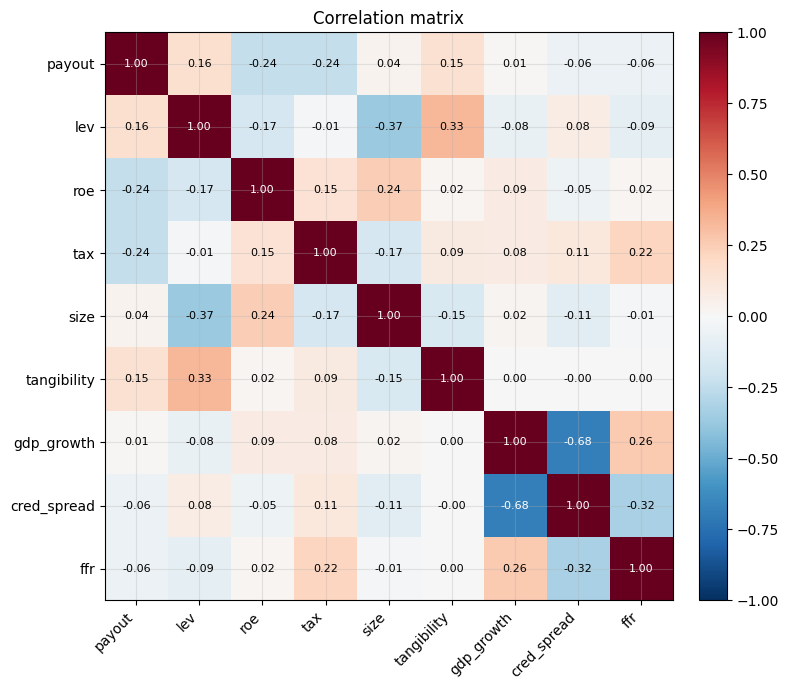

In [26]:
# Fig 1 — correlation heatmap
cv = [c for c in ["payout", "lev", "roe", "tax", "size", "tangibility",
                  "gdp_growth", "cred_spread", "ffr"] if c in panel and panel[c].notna().any()]
C = panel[cv].corr()
fig, ax = plt.subplots(figsize=(8, 7)); im = ax.imshow(C.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(cv))); ax.set_xticklabels(cv, rotation=45, ha="right")
ax.set_yticks(range(len(cv))); ax.set_yticklabels(cv)
for i in range(len(cv)):
    for j in range(len(cv)):
        v = C.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(v) > .55 else "black")
fig.colorbar(im, fraction=0.046, pad=0.04); ax.set_title("Correlation matrix")
fig.tight_layout(); fig.savefig(OUTDIR / "fig_corr_heatmap.png", dpi=150); plt.show()

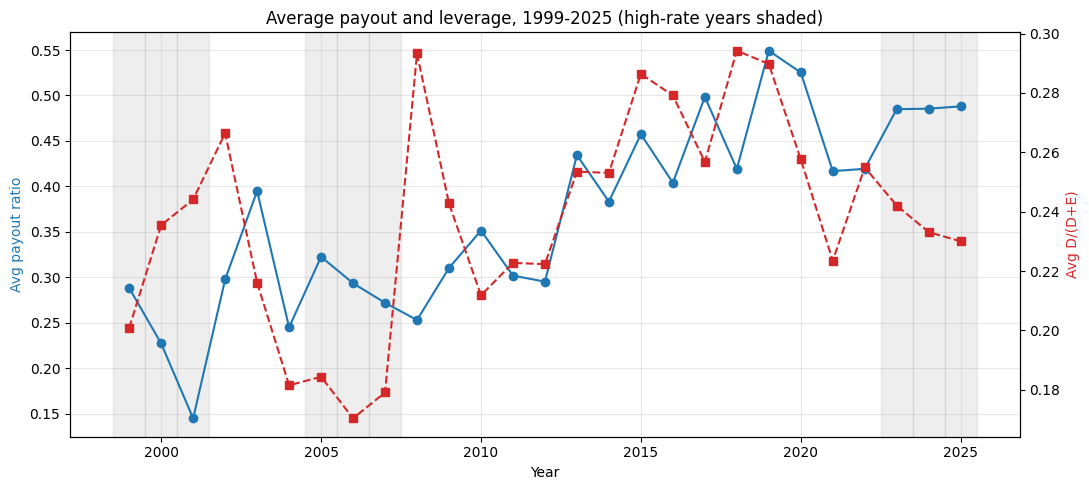

In [27]:
# Fig 2 — avg payout & leverage over time, high-rate years shaded
ts = panel.groupby("year")[["payout", "lev"]].mean()
hi_years = set(macro.loc[macro.high_rate == 1, "year"])
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(ts.index, ts["payout"], "o-", color="tab:blue", label="Avg payout")
ax1.set_ylabel("Avg payout ratio", color="tab:blue"); ax2 = ax1.twinx()
ax2.plot(ts.index, ts["lev"], "s--", color="tab:red", label="Avg leverage")
ax2.set_ylabel("Avg D/(D+E)", color="tab:red"); ax2.grid(False)
for y in hi_years:
    if y in ts.index: ax1.axvspan(y - .5, y + .5, color="gray", alpha=.13)
ax1.set_title("Average payout and leverage, 1999-2025 (high-rate years shaded)")
ax1.set_xlabel("Year"); fig.tight_layout()
fig.savefig(OUTDIR / "fig_payout_leverage_ts.png", dpi=150); plt.show()

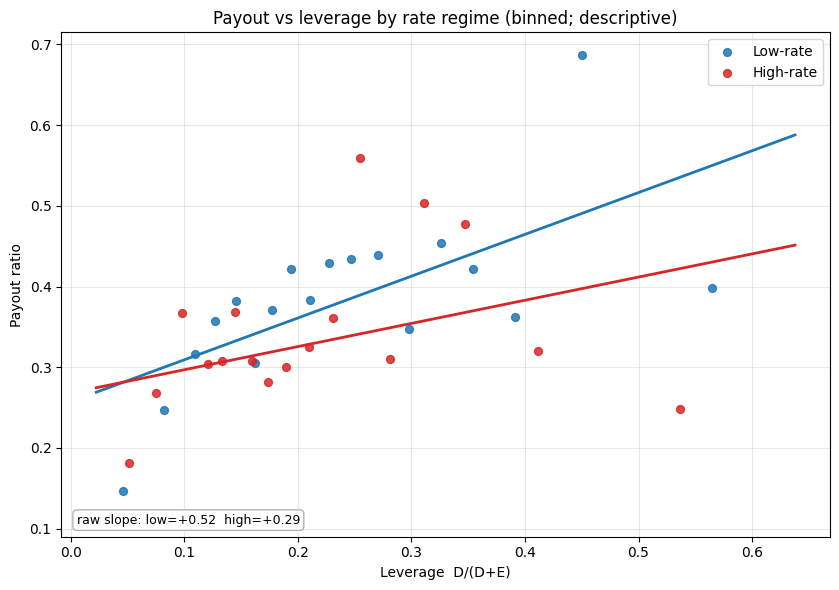

In [28]:
# Fig 3 — KEY H1/H2 visual: binned payout vs leverage by regime
def binscatter(ax, d, x, y, color, label, nbins=18):
    d = d[[x, y]].dropna(); q = min(nbins, d[x].nunique())
    d = d.assign(_b=pd.qcut(d[x], q, duplicates="drop"))
    g = d.groupby("_b").agg(xx=(x, "mean"), yy=(y, "mean"))
    ax.scatter(g["xx"], g["yy"], s=32, color=color, alpha=.85, label=label, zorder=3)
    b = np.polyfit(d[x], d[y], 1); xs = np.linspace(d[x].min(), d[x].max(), 50)
    ax.plot(xs, np.polyval(b, xs), color=color, lw=2)
    return b[0]
fig, ax = plt.subplots(figsize=(8.5, 6))
sl = binscatter(ax, panel[panel.high_rate == 0], "lev", "payout", "tab:blue", "Low-rate")
sh = binscatter(ax, panel[panel.high_rate == 1], "lev", "payout", "tab:red", "High-rate")
ax.set_xlabel("Leverage  D/(D+E)"); ax.set_ylabel("Payout ratio")
ax.set_title("Payout vs leverage by rate regime (binned; descriptive)")
ax.text(.02, .02, f"raw slope: low={sl:+.2f}  high={sh:+.2f}", transform=ax.transAxes,
        fontsize=9, va="bottom", bbox=dict(boxstyle="round", fc="white", ec="0.7"))
ax.legend(); fig.tight_layout()
fig.savefig(OUTDIR / "fig_payout_vs_leverage_by_regime.png", dpi=150); plt.show()

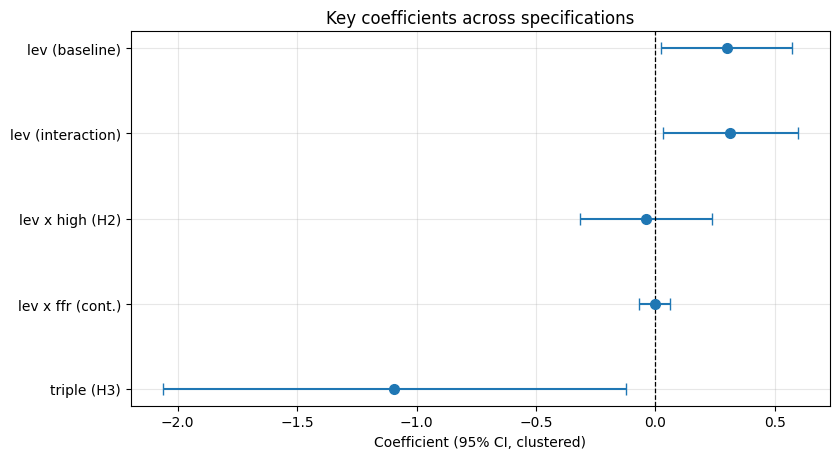

In [29]:
# Fig 4 — coefficient forest plot
def grab(res, key, label):
    if res is None or not hasattr(res, "params") or key not in res.params: return None
    b = res.params[key]; se = res.std_errors[key]; return (label, b, b - 1.96 * se, b + 1.96 * se)
specs = [grab(res_base, "lev", "lev (baseline)"), grab(res_int, "lev", "lev (interaction)"),
         grab(res_int, "lev_x_high", "lev x high (H2)"), grab(res_cont, "lev_x_ffr", "lev x ffr (cont.)"),
         grab(res_h3, "lev_x_high_x_tang", "triple (H3)") if "res_h3" in globals() else None]
specs = [s for s in specs if s]
fig, ax = plt.subplots(figsize=(8.5, .7 * len(specs) + 1.2))
for i, (lab, b, lo, hi) in enumerate(specs):
    ax.errorbar(b, i, xerr=[[b - lo], [hi - b]], fmt="o", color="tab:blue", capsize=4, markersize=7)
ax.axvline(0, color="k", lw=.9, ls="--"); ax.set_yticks(range(len(specs)))
ax.set_yticklabels([s[0] for s in specs]); ax.invert_yaxis()
ax.set_xlabel("Coefficient (95% CI, clustered)"); ax.set_title("Key coefficients across specifications")
fig.tight_layout(); fig.savefig(OUTDIR / "fig_coefficient_forest.png", dpi=150); plt.show()

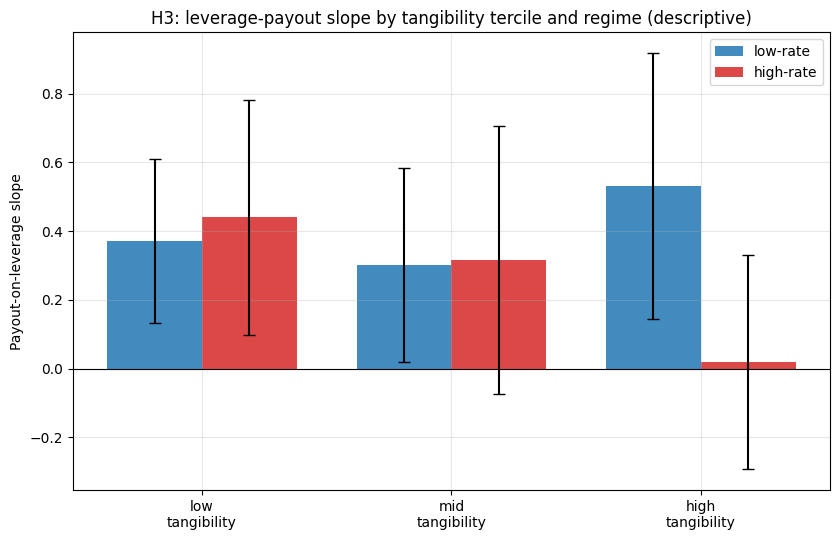

In [30]:
# Fig 5 — H3: payout~leverage slope by tangibility tercile x regime
import statsmodels.formula.api as smf
if panel["tangibility"].notna().any():
    panel["tang_grp"] = pd.qcut(panel["tangibility"], 3, labels=["low", "mid", "high"], duplicates="drop")
    cells = []
    for g in ["low", "mid", "high"]:
        for hr, lab in [(0, "low-rate"), (1, "high-rate")]:
            sub = panel[(panel.tang_grp == g) & (panel.high_rate == hr)][["payout", "lev"]].dropna()
            if len(sub) > 10:
                m = smf.ols("payout ~ lev", sub).fit(cov_type="HC1")
                cells.append((g, lab, m.params["lev"], m.bse["lev"]))
    cdf = pd.DataFrame(cells, columns=["tang", "regime", "slope", "se"])
    groups = ["low", "mid", "high"]; x = np.arange(len(groups)); w = .38
    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    for k, (reg, col) in enumerate([("low-rate", "tab:blue"), ("high-rate", "tab:red")]):
        s = cdf[cdf.regime == reg].set_index("tang").reindex(groups)
        ax.bar(x + (k - .5) * w, s["slope"], w, yerr=1.96 * s["se"], capsize=4, color=col, label=reg, alpha=.85)
    ax.axhline(0, color="k", lw=.8); ax.set_xticks(x); ax.set_xticklabels([f"{g}\ntangibility" for g in groups])
    ax.set_ylabel("Payout-on-leverage slope"); ax.legend()
    ax.set_title("H3: leverage-payout slope by tangibility tercile and regime (descriptive)")
    fig.tight_layout(); fig.savefig(OUTDIR / "fig_H3_slopes_by_tangibility.png", dpi=150); plt.show()

## 12 · Reproducibility & outputs  <span style="color:gray">(Appendices B & D)</span>

In [31]:
# Appendix B — industry persistence table
appendix_B = (persist.rename("years_present").reset_index()
              .assign(in_core=lambda d: d["industry"].isin(CORE)))
appendix_B.to_csv(OUTDIR / "appendix_B_industry_persistence.csv", index=False)
pd.Series(INDUSTRY_RENAME, name="canonical").rename_axis("original").to_csv(OUTDIR / "appendix_B_rename_map.csv")

panel.to_csv(OUTDIR / "analysis_panel.csv", index=False)
try: panel.to_parquet(OUTDIR / "analysis_panel.parquet", index=False)
except Exception: pass

print(f"Saved {len(list(OUTDIR.glob('*')))} files to {OUTDIR}/\n")
print(f"Panel: {panel['industry'].nunique()} industries x {panel['year'].nunique()} years "
      f"({panel.year.min()}-{panel.year.max()}) = {len(panel)} obs; core = {len(CORE)} industries\n")
for m in ["pandas", "numpy", "matplotlib", "statsmodels", "linearmodels", "xlrd"]:
    try: print(f"  {m:13s}", __import__(m).__version__)
    except Exception: print(f"  {m:13s} (missing)")
print("  python       ", sys.version.split()[0])

Saved 31 files to outputs/

Panel: 143 industries x 27 years (1999-2025) = 2116 obs; core = 46 industries

  pandas        3.0.2
  numpy         2.4.4
  matplotlib    3.10.9
  statsmodels   0.15.0
  linearmodels  7.0
  xlrd          2.0.2
  python        3.11.15


---
### Summary

- **Full 1999–2025 industry panel** built reproducibly from the Damodaran archives (era-proof loader) plus
  FRED macro data. Sample: US non-financial, non-utility industries.
- **Hypotheses tested directly:** H1/H2 via the `lev × HighRate` interaction (primary regime = rate-level
  threshold; post-2022 binary as robustness); H3 via the `lev × HighRate × tangibility` triple interaction.
- **Industry reconciliation** (Appendix B) handles Damodaran's 2012→2013 reclassification conservatively;
  a **stable-core sample** provides a robustness check immune to it.
- **Tangibility (H3)** is PP&E / total assets (within-year rank); the capex-based proxies are robustness checks.
- **Alternative leverage (§9d):** market leverage without leases, book leverage and Debt/EBITDA (debt relative
  to cash flow, also interacted with the fed funds rate as an interest-burden proxy).
- **H3 fragility (§10b):** the negative triple term survives dropping any single industry, but not dropping
  the 2023–2025 episode, and it is not significant at 5% after adjusting for multiple testing: exploratory.
- **Data-quality fixes:** depreciation-based tangibility excluded in 2013–2015 (capex depreciation break);
  rows whose firm count does not match `divfund` (a shifted block in `wacc99`) set to missing;
  ratios with a non-positive denominator (payout when ROE ≤ 0, Dividends/FCFE when FCFE ≤ 0) set to missing;
  H3 includes the tangibility main effect; macro controls enter only the industry-FE-only specification.
- **Power and bounds (§9b):** the H2 null is reported as a bound: the confidence interval rules out
  regime effects above a few payout points per SD of leverage, while smaller effects cannot be excluded.
- **Dividend smoothing (§8b):** dividends adjust slowly toward a target payout (Lintner), smoothing does not
  change across rate regimes, and H1 tested in change form (dividend changes) is not supported either.
- **Outputs** (`outputs/`): combined regression table (CSV + LaTeX), hypothesis verdicts, descriptive and
  proxy-robustness tables, the variable and industry appendices, and six publication-ready figures.
- **Caveats to read in the thesis:** PP&E / assets changes definition in 2013 and 2017 (hence the ranks);
  the main leverage measure includes leases from 2013 on;
  industry-level aggregation; the data is a repeated cross-section; results are associational.